# Chapter 7: Advanced Regression

## Author: Rahul Bhadani

# 1. Kernel Functions

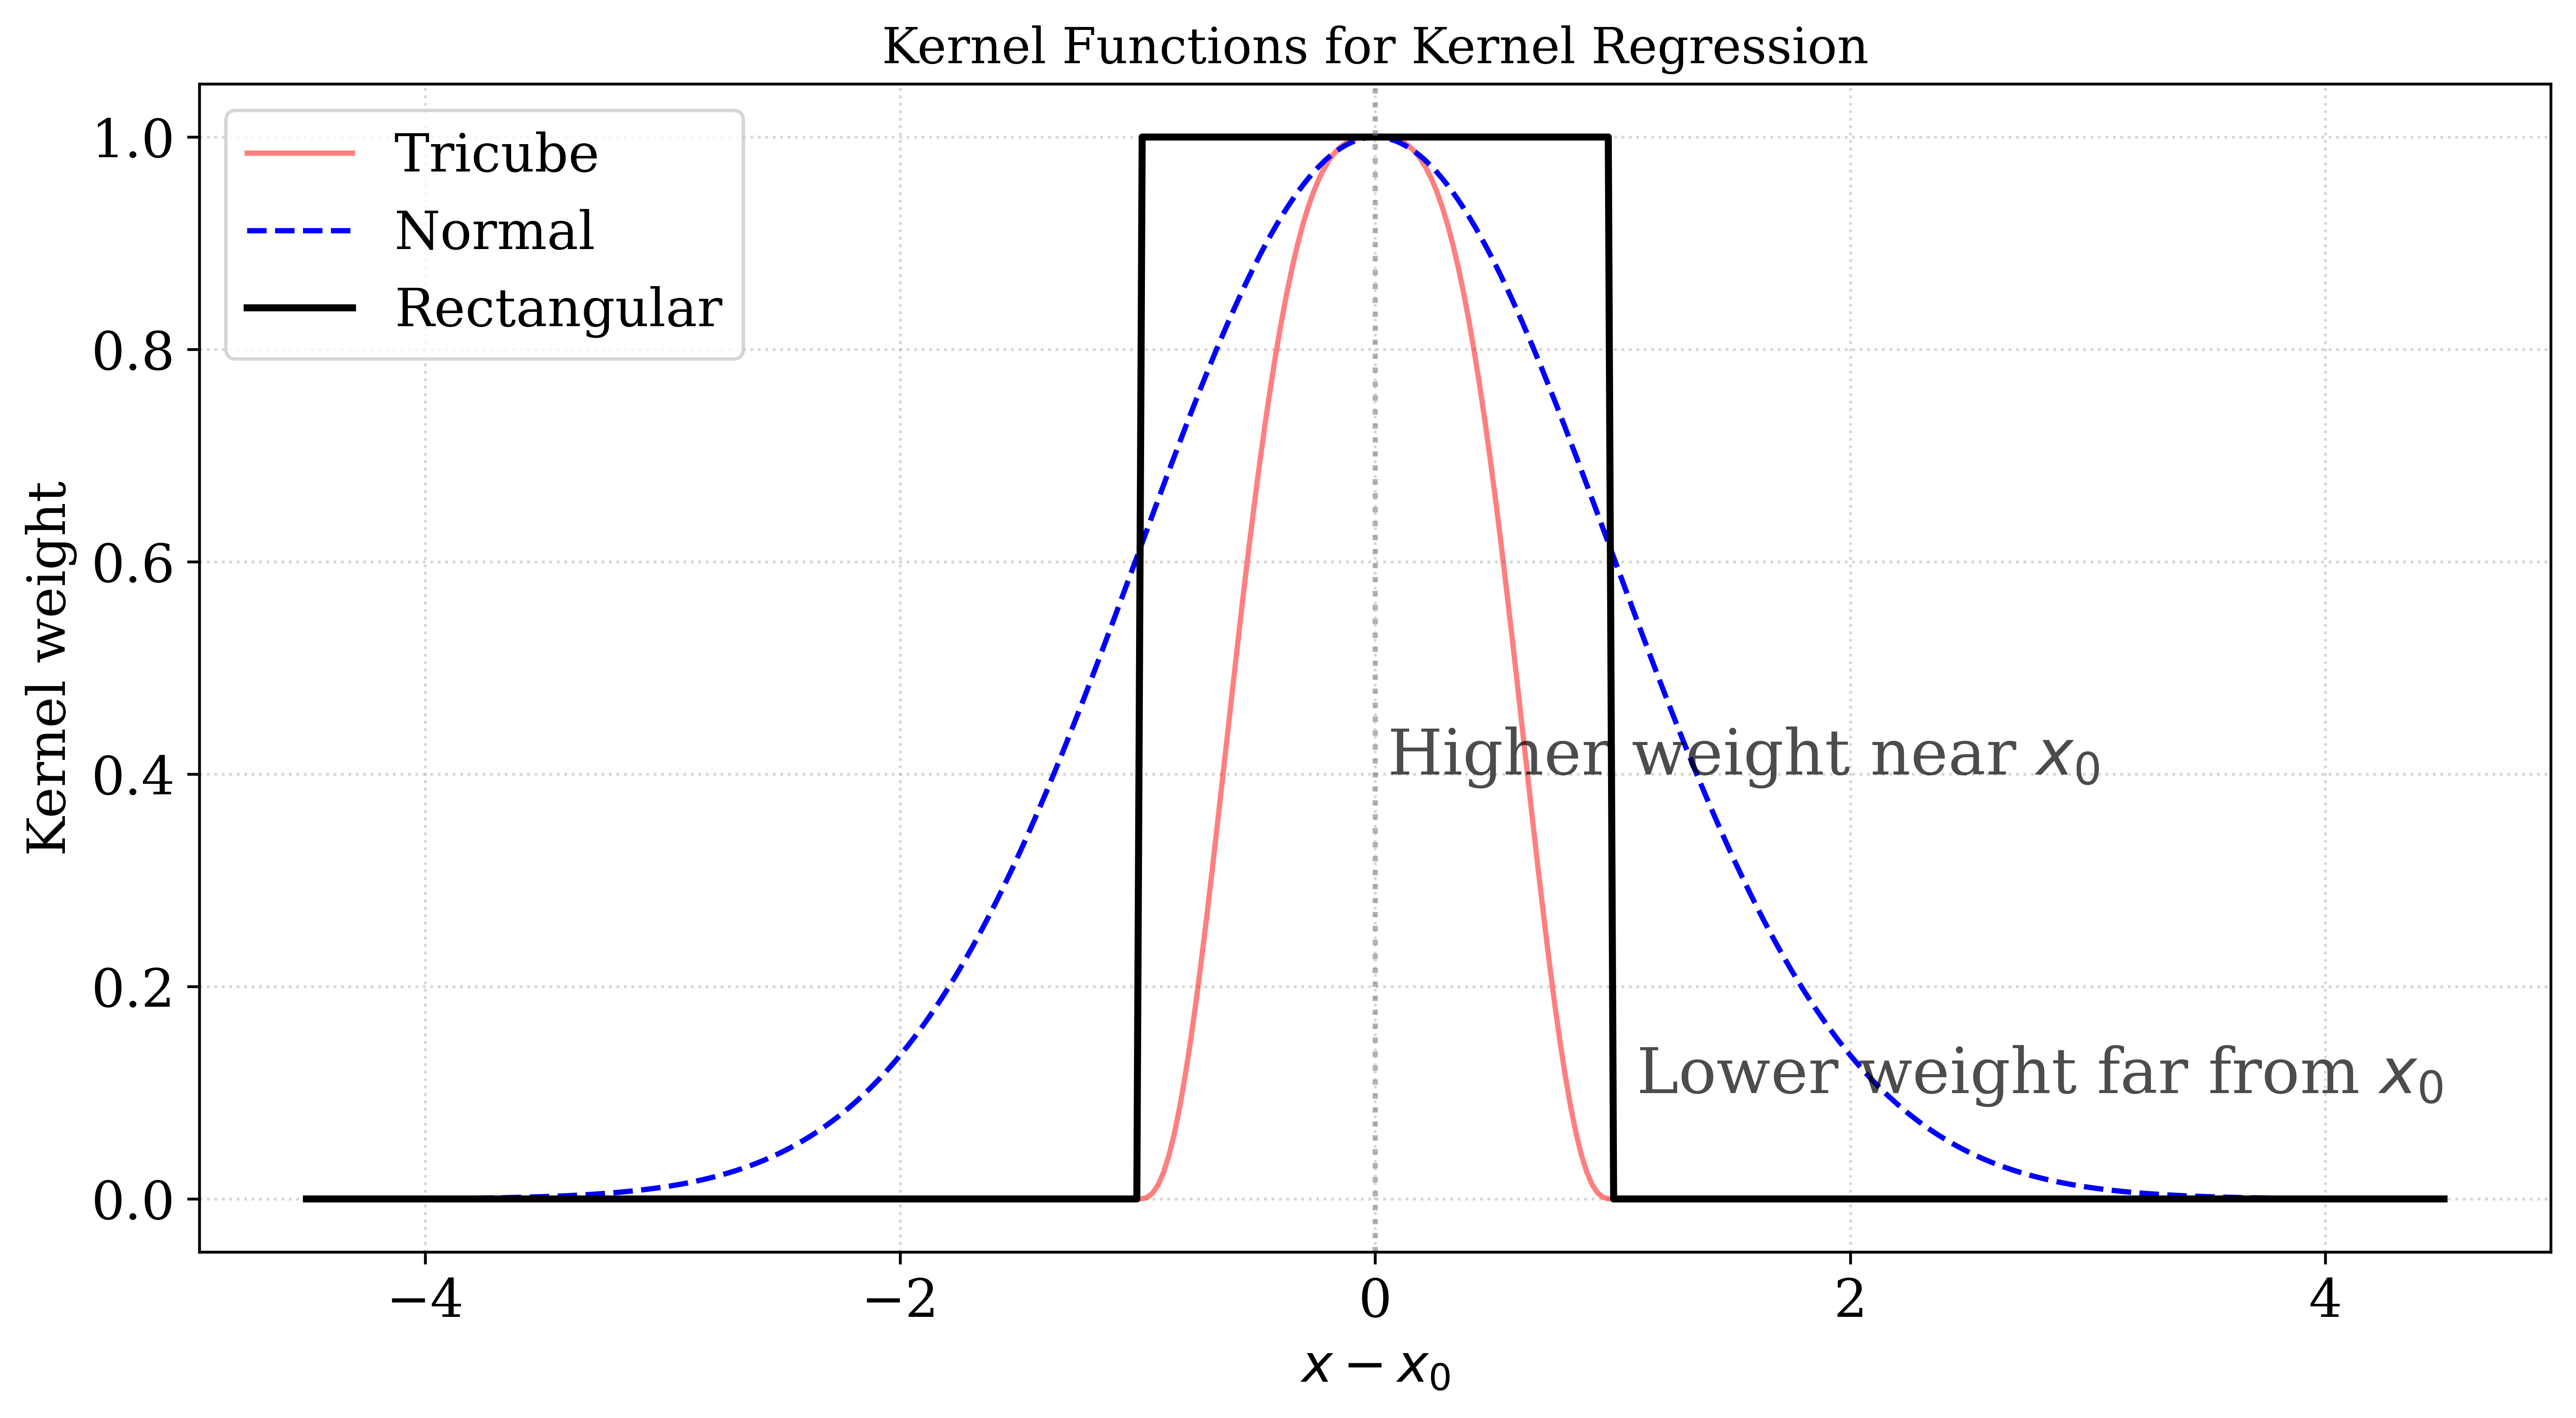

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['font.size'] = 15
from scipy.stats import norm

def tricube_kernel(x):
    """Tricube kernel function scaled to max 1."""
    abs_x = np.abs(x)
    return np.where(abs_x < 1, ((70 / 81) * (1 - abs_x**3) ** 3) / (70 / 81), 0)

def rectangular_kernel(x):
    """Rectangular (uniform) kernel function scaled to max 1."""
    return np.where(np.abs(x) < 1, 1, 0)

def normal_kernel(x):
    """Normal (Gaussian) kernel function, rescaled to max 1."""
    return norm.pdf(x) / norm.pdf(0)

# Generate x values
x = np.linspace(-4.5, 4.5, 400)

# Compute kernel values
y_tricube = tricube_kernel(x)
y_normal = normal_kernel(x)
y_rectangular = rectangular_kernel(x)

# Plot the kernel functions
plt.figure(figsize=(12, 6), dpi=600)
plt.plot(x, y_tricube, 'r', linestyle='-', alpha=0.5, label='Tricube')
plt.plot(x, y_normal, 'b--', label='Normal')
plt.plot(x, y_rectangular, 'k', linewidth=2, label='Rectangular')

# Highlight kernel regression concept
plt.axvline(0, color='gray', linestyle=':', alpha=0.6)
plt.text(0.05, 0.4, 'Higher weight near $x_0$', fontsize=18, color='black', alpha=0.7)
plt.text(1.1, 0.1, 'Lower weight far from $x_0$', fontsize=18, color='black', alpha=0.7)

# Labels and legend
plt.xlabel('$x - x_0$', fontsize=15)
plt.ylabel('Kernel weight', fontsize=15)
plt.title('Kernel Functions for Kernel Regression', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.savefig('figures/loess_kernel.pdf', transparent=True)
plt.show()

# 2. Synthetic Dataset Generation with Linear Model

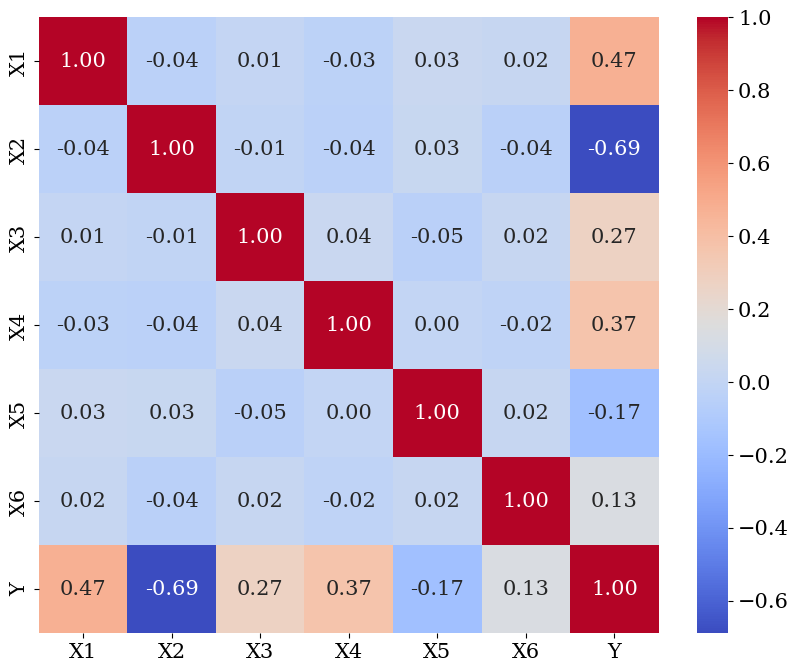

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Set seed for reproducibility
np.random.seed(420)

# Step 2: Generate synthetic data
n_samples = 1000  # Number of samples
n_features = 6    # Number of features

# Generate random feature values (X) from a normal distribution
X = np.random.randn(n_samples, n_features)

# Define coefficients (betas) for the linear model
betas = np.array([1.5, -2.0, 0.8, 1.2, -0.5, 0.3])

# Generate random noise (epsilon)
epsilon = np.random.normal(0, 1, n_samples)

# Compute the response variable Y using the linear equation
Y = np.dot(X, betas) + epsilon

# Step 3: Create a DataFrame
columns = [f'X{i+1}' for i in range(n_features)]  # Feature names
data = pd.DataFrame(X, columns=columns)
data['Y'] = Y  # Add the response variable to the DataFrame

# Step 4: Compute the correlation matrix
correlation_matrix = data.corr()

# Step 5: Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
#plt.title('Correlation Matrix Heatmap')
plt.savefig('figures/heatmap_interaction.pdf', transparent=True)
plt.show()

# 3. Residual Plotting


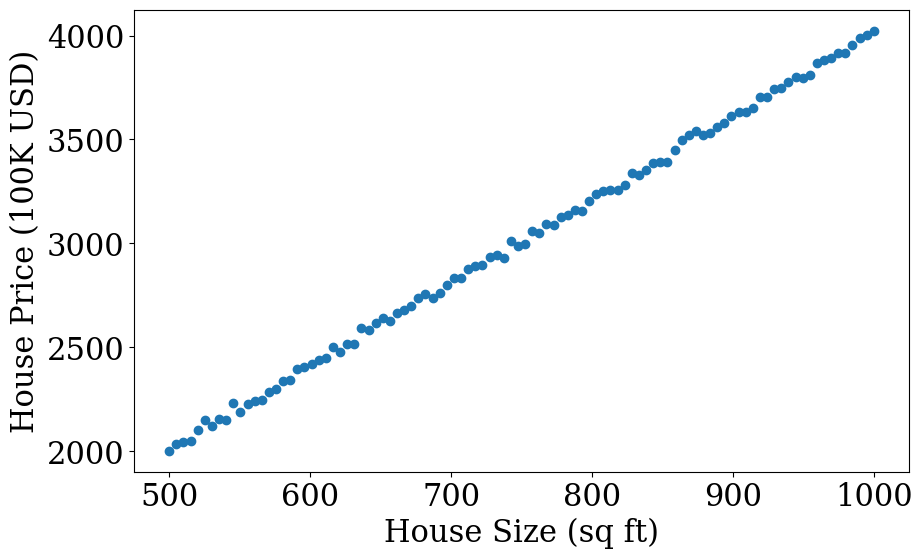

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['font.size'] = 22

# Generate x values
x = np.linspace(500, 1000, 100)

# Create a line equation
y = 4.0*x + 7.0

# Add Gaussian noise
mu = 0  # Mean of the Gaussian noise
sigma = 20  # Standard deviation of the Gaussian noise
noise = np.random.normal(mu, sigma, y.shape)
y_noisy = y + noise

## Make a plot
# Plot the results
fig, ax = plt.subplots(figsize=(10, 6))
plt.scatter(x, y_noisy)
fig.patch.set_alpha(0.0)
plt.xlabel('House Size (sq ft)')
plt.ylabel('House Price (100K USD)')
plt.show()



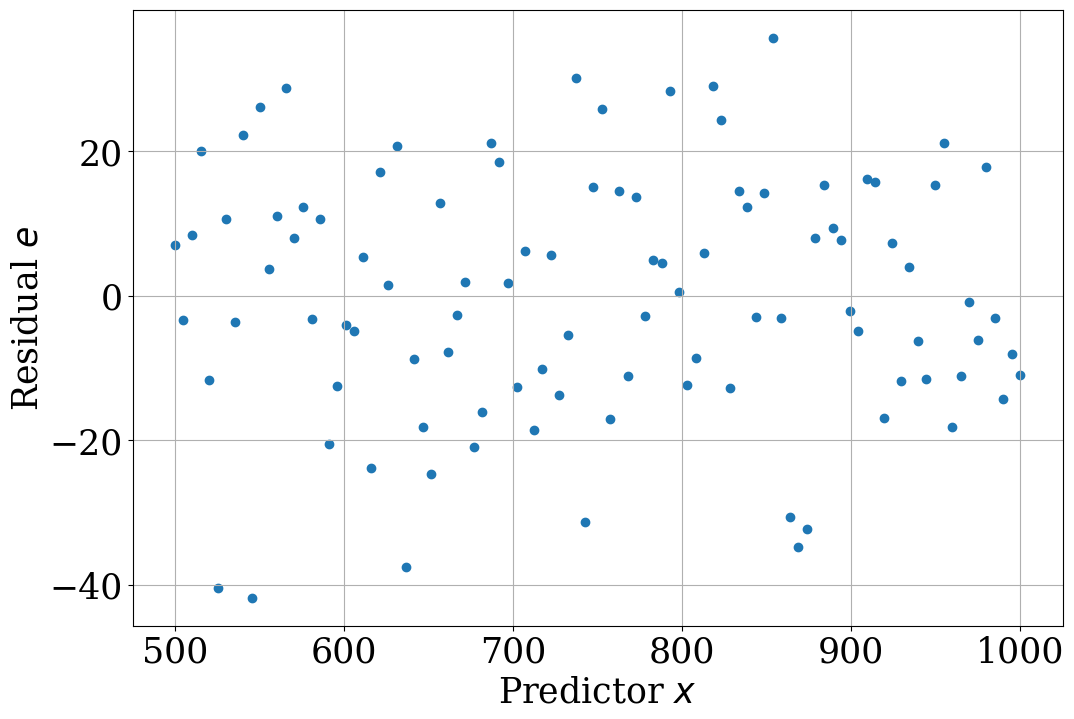

In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
plt.rcParams['font.size'] = 25
linearModel = LinearRegression()
linearModel.fit(x.reshape(-1, 1), y_noisy)
yhat = linearModel.predict(x.reshape(-1, 1))
error = yhat - y_noisy
fig, ax = plt.subplots(figsize=(12, 8))
plt.scatter(x, error)
fig.patch.set_alpha(0.0)
plt.xlabel('Predictor $x$', fontsize=25)
plt.ylabel('Residual $e$', fontsize=25)
plt.grid(which='both')
plt.savefig('figures/normal_residual_plot.pdf', transparent=True)
plt.show()


<Figure size 400x800 with 0 Axes>

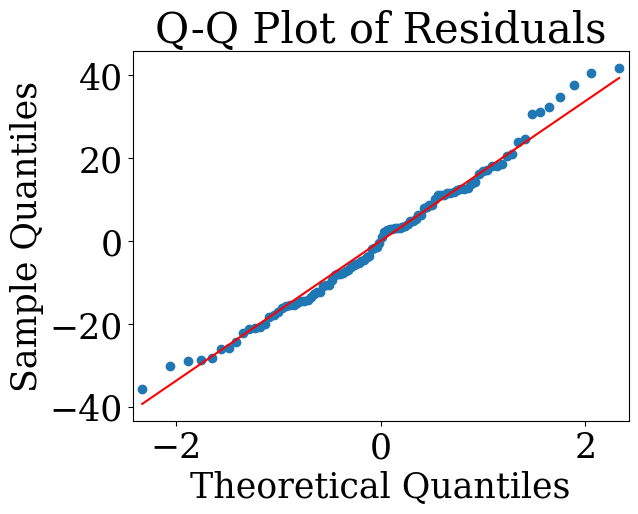

In [9]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Assume X and y are your data
x = sm.add_constant(x)  # Adds a constant term to the predictor
model = sm.OLS(y_noisy, x).fit()

# Get the residuals
residuals = model.resid

# Create Q-Q plot
plt.figure(figsize=(4, 8))
sm.qqplot(residuals, line='s')  # 's' adds a reference line
plt.title('Q-Q Plot of Residuals')
plt.savefig('figures/qq_plot.pdf', transparent=True)
plt.show()

or

((array([-2.46203784, -2.12570747, -1.93122778, -1.79044653, -1.67819304,
         -1.58381122, -1.50174123, -1.42869743, -1.36256869, -1.30191411,
         -1.24570419, -1.19317644, -1.14374949, -1.09696931, -1.05247413,
         -1.00997067, -0.96921765, -0.93001393, -0.89218993, -0.85560121,
         -0.82012357, -0.78564937, -0.75208458, -0.71934648, -0.68736185,
         -0.65606548, -0.62539893, -0.59530962, -0.56574992, -0.53667655,
         -0.50804994, -0.47983378, -0.45199463, -0.42450149, -0.39732558,
         -0.37044003, -0.34381966, -0.31744076, -0.29128096, -0.26531902,
         -0.23953472, -0.21390872, -0.18842244, -0.16305799, -0.13779803,
         -0.1126257 , -0.08752455, -0.06247843, -0.03747145, -0.01248789,
          0.01248789,  0.03747145,  0.06247843,  0.08752455,  0.1126257 ,
          0.13779803,  0.16305799,  0.18842244,  0.21390872,  0.23953472,
          0.26531902,  0.29128096,  0.31744076,  0.34381966,  0.37044003,
          0.39732558,  0.42450149,  0.

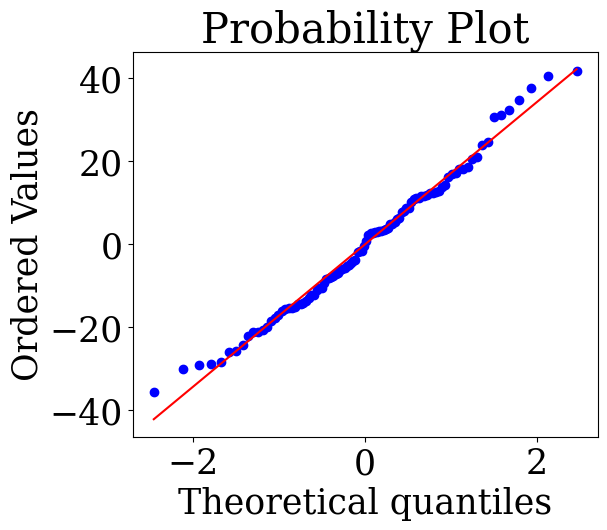

In [13]:
from scipy import stats
# Create Q-Q plot
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5))
stats.probplot(residuals, dist="norm", plot=ax1)

REGRESSION DIAGNOSTICS PROBLEM SET

### DATASET 1: Multicollinearity ###

Variance Inflation Factors (VIF):
  Feature          VIF
0      X1  2630.409715
1      X2  1534.629077
2      X3   293.424349
3      X4    13.290052
4      X5    11.975159
5      X6  2491.481593

Interpretation:
VIF > 10: Severe multicollinearity
VIF 5-10: Moderate multicollinearity
VIF < 5: Low multicollinearity


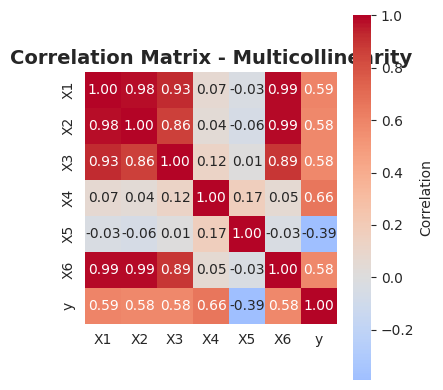

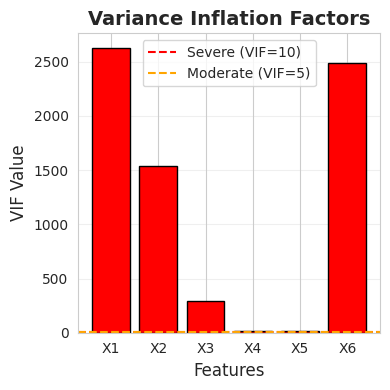


### DATASET 2: Heteroscedasticity ###



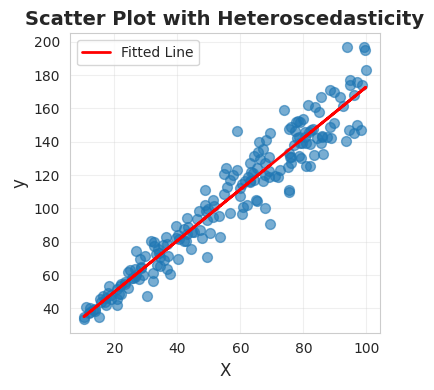

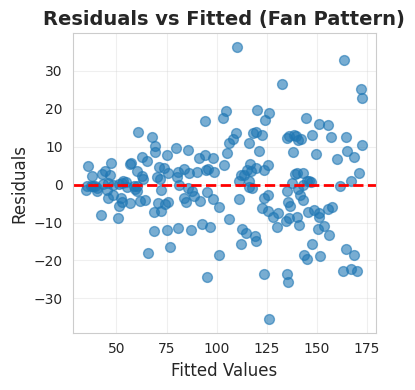

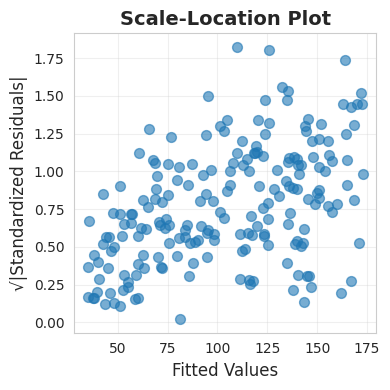

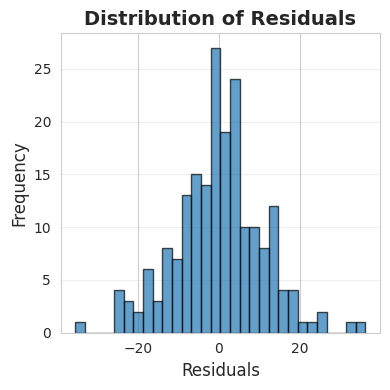

Breusch-Pagan test would be appropriate here to test for heteroscedasticity

### DATASET 3: Non-Normality of Residuals ###

Shapiro-Wilk Test: W=0.8695, p-value=0.000000


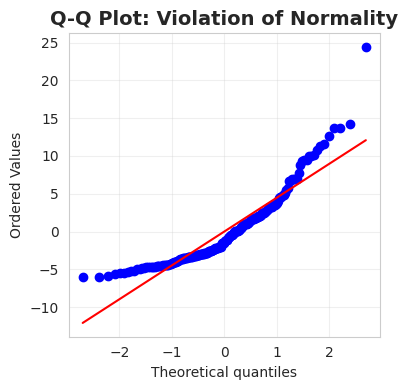

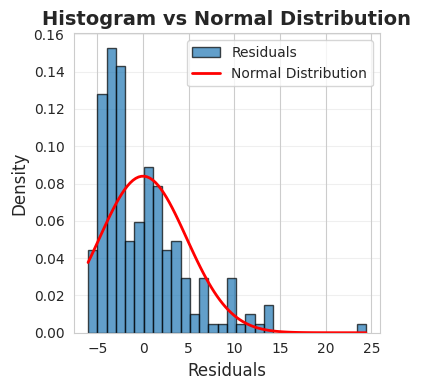

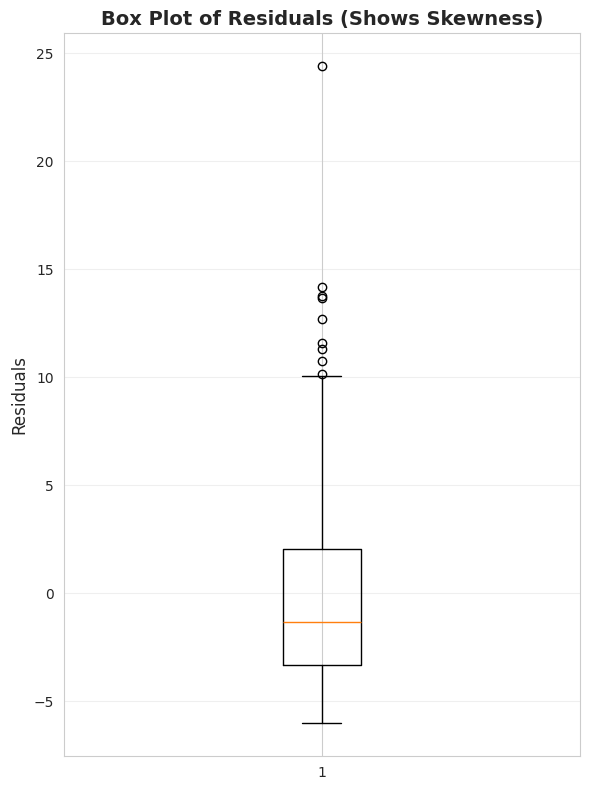

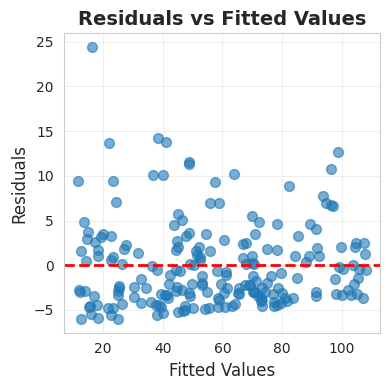

Skewness: 1.5554
Kurtosis: 3.3607

### DATASET 4: Non-Linearity ###



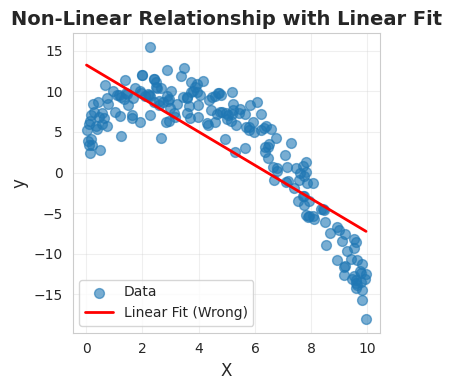

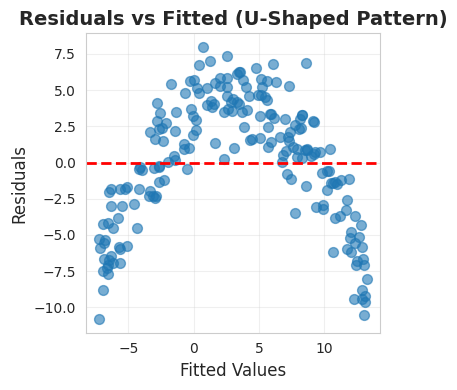

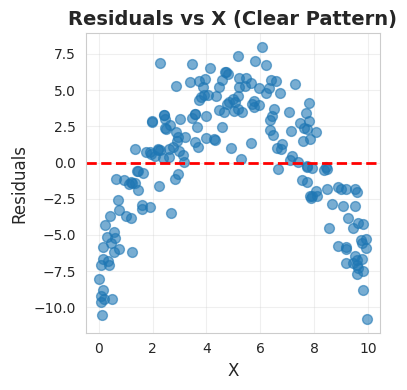

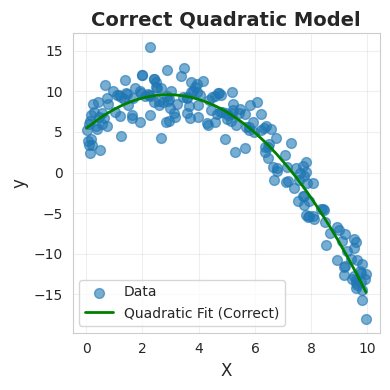


### DATASET 5: Outliers and Influential Points ###



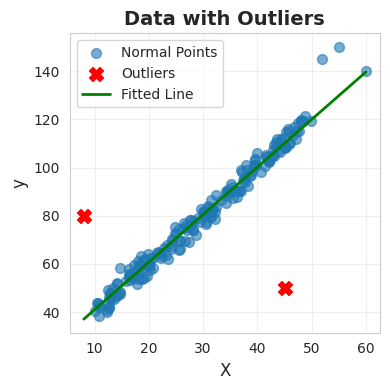

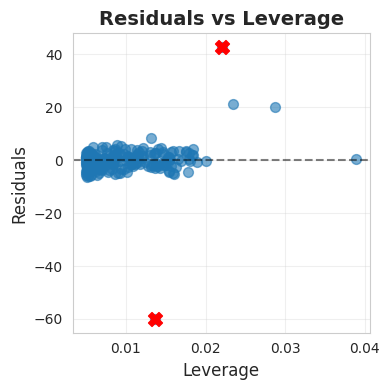

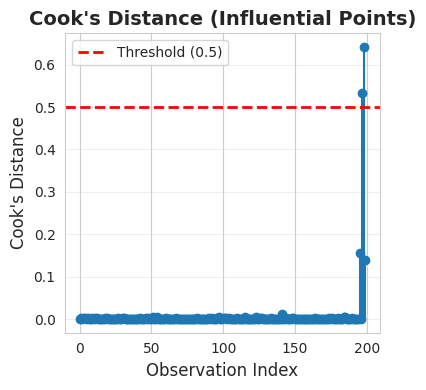

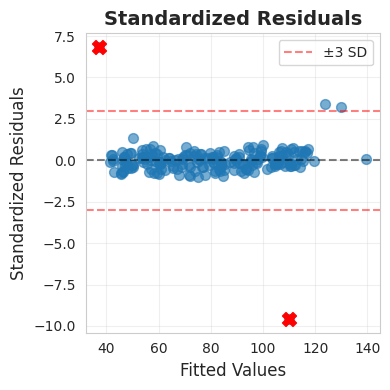

Number of influential points (Cook's D > 0.5): 2

### DATASET 6: Autocorrelation in Residuals ###



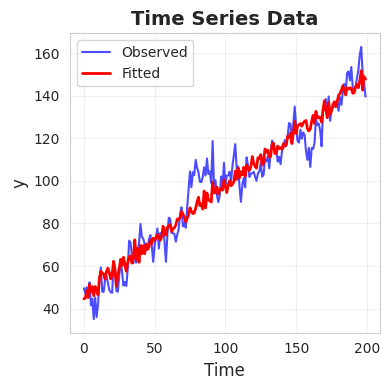

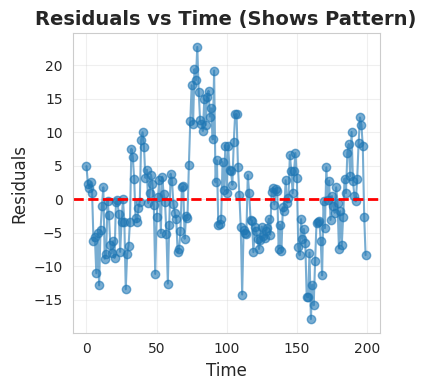

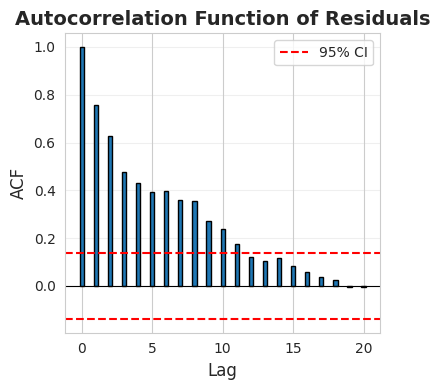

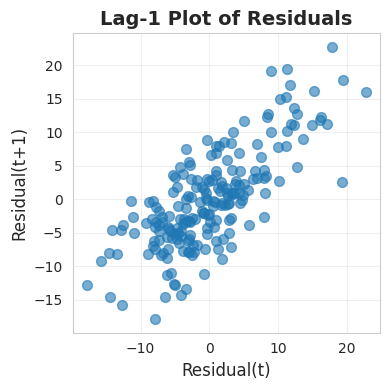

Durbin-Watson Statistic: 0.4861
Interpretation: DW ≈ 2 suggests no autocorrelation
               DW < 2 suggests positive autocorrelation
               DW > 2 suggests negative autocorrelation

ALL FIGURES SAVED TO 'figures/' FOLDER AS PDF FILES

Total figures generated: 24

Dataset 1 - Multicollinearity: 2 figures
Dataset 2 - Heteroscedasticity: 4 figures
Dataset 3 - Non-Normality: 4 figures
Dataset 4 - Non-Linearity: 4 figures
Dataset 5 - Outliers: 4 figures
Dataset 6 - Autocorrelation: 4 figures

ASSESSMENT QUESTIONS FOR STUDENTS

1. MULTICOLLINEARITY:
   - Which features show high multicollinearity?
   - What is the VIF threshold for concern?
   - How would you address multicollinearity?

2. HETEROSCEDASTICITY:
   - Describe the pattern in the residuals vs fitted plot
   - What transformation might fix heteroscedasticity?
   - How does it violate OLS assumptions?

3. NON-NORMALITY:
   - Is the Q-Q plot linear? What does this indicate?
   - What is the p-value from Shapiro-Wilk te

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os

# Create figures directory if it doesn't exist
os.makedirs('figures', exist_ok=True)

# Set style
sns.set_style("whitegrid")
np.random.seed(42)

# Generate sample size
n = 200

print("="*80)
print("REGRESSION DIAGNOSTICS PROBLEM SET")
print("="*80)

# =============================================================================
# DATASET 1: MULTICOLLINEARITY DEMONSTRATION
# =============================================================================
print("\n### DATASET 1: Multicollinearity ###\n")

# Generate highly correlated features
X1 = np.random.normal(50, 10, n)
X2 = X1 + np.random.normal(0, 2, n)  # Highly correlated with X1
X3 = 2*X1 - X2 + np.random.normal(0, 3, n)  # Linear combination
X4 = np.random.normal(30, 8, n)  # Independent
X5 = np.random.normal(40, 12, n)  # Independent
X6 = 0.5*X1 + 0.5*X2 + np.random.normal(0, 1, n)  # Correlated with X1 and X2

# Generate target with normal errors
y1 = 5 + 2*X1 + 3*X4 - 1.5*X5 + np.random.normal(0, 5, n)

# Create dataframe
df1 = pd.DataFrame({
    'X1': X1, 'X2': X2, 'X3': X3, 'X4': X4, 'X5': X5, 'X6': X6, 'y': y1
})

# Calculate correlation matrix
corr_matrix = df1.corr()

# Calculate VIF
X_multi = df1[['X1', 'X2', 'X3', 'X4', 'X5', 'X6']].values
vif_data = pd.DataFrame()
vif_data["Feature"] = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
vif_data["VIF"] = [variance_inflation_factor(X_multi, i) for i in range(X_multi.shape[1])]

print("Variance Inflation Factors (VIF):")
print(vif_data)
print("\nInterpretation:")
print("VIF > 10: Severe multicollinearity")
print("VIF 5-10: Moderate multicollinearity")
print("VIF < 5: Low multicollinearity")

# Plot 1a: Correlation heatmap
fig = plt.figure(figsize=(4, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - Multicollinearity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/plot1a_correlation_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 1b: VIF bar plot
fig = plt.figure(figsize=(4, 4))
colors = ['red' if v > 10 else 'orange' if v > 5 else 'green' for v in vif_data['VIF']]
plt.bar(vif_data['Feature'], vif_data['VIF'], color=colors, edgecolor='black')
plt.axhline(y=10, color='red', linestyle='--', label='Severe (VIF=10)')
plt.axhline(y=5, color='orange', linestyle='--', label='Moderate (VIF=5)')
plt.ylabel('VIF Value', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.title('Variance Inflation Factors', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot1b_vif_barplot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# DATASET 2: HETEROSCEDASTICITY
# =============================================================================
print("\n### DATASET 2: Heteroscedasticity ###\n")

X_hetero = np.random.uniform(10, 100, n)
# Error variance increases with X (fan shape)
errors_hetero = np.random.normal(0, X_hetero/5, n)
y_hetero = 20 + 1.5*X_hetero + errors_hetero

# Fit model
model_hetero = LinearRegression()
model_hetero.fit(X_hetero.reshape(-1, 1), y_hetero)
y_pred_hetero = model_hetero.predict(X_hetero.reshape(-1, 1))
residuals_hetero = y_hetero - y_pred_hetero

# Plot 2a: Scatter plot with regression line
fig = plt.figure(figsize=(4, 4))
plt.scatter(X_hetero, y_hetero, alpha=0.6, s=50)
plt.plot(X_hetero, y_pred_hetero, 'r-', linewidth=2, label='Fitted Line')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Scatter Plot with Heteroscedasticity', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot2a_scatter_heteroscedasticity.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2b: Residuals vs Fitted
fig = plt.figure(figsize=(4, 4))
plt.scatter(y_pred_hetero, residuals_hetero, alpha=0.6, s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Fitted (Fan Pattern)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot2b_residuals_vs_fitted.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2c: Scale-Location plot
fig = plt.figure(figsize=(4, 4))
standardized_residuals = residuals_hetero / np.std(residuals_hetero)
plt.scatter(y_pred_hetero, np.sqrt(np.abs(standardized_residuals)), alpha=0.6, s=50)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('√|Standardized Residuals|', fontsize=12)
plt.title('Scale-Location Plot', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot2c_scale_location.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2d: Histogram of residuals
fig = plt.figure(figsize=(4, 4))
plt.hist(residuals_hetero, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot2d_residuals_histogram.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Breusch-Pagan test would be appropriate here to test for heteroscedasticity")

# =============================================================================
# DATASET 3: NON-NORMALITY OF RESIDUALS
# =============================================================================
print("\n### DATASET 3: Non-Normality of Residuals ###\n")

X_normal = np.random.uniform(0, 50, n)
# Generate non-normal errors (exponential distribution - right skewed)
errors_nonnormal = np.random.exponential(scale=5, size=n) - 5
y_nonnormal = 10 + 2*X_normal + errors_nonnormal

# Fit model
model_nonnormal = LinearRegression()
model_nonnormal.fit(X_normal.reshape(-1, 1), y_nonnormal)
y_pred_nonnormal = model_nonnormal.predict(X_normal.reshape(-1, 1))
residuals_nonnormal = y_nonnormal - y_pred_nonnormal

# Shapiro-Wilk test
shapiro_stat, shapiro_pval = stats.shapiro(residuals_nonnormal)
print(f"Shapiro-Wilk Test: W={shapiro_stat:.4f}, p-value={shapiro_pval:.6f}")

# Plot 3a: Q-Q Plot
fig = plt.figure(figsize=(4, 4))
stats.probplot(residuals_nonnormal, dist="norm", plot=plt)
plt.title('Q-Q Plot: Violation of Normality', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot3a_qq_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3b: Histogram with normal curve overlay
fig = plt.figure(figsize=(4, 4))
plt.hist(residuals_nonnormal, bins=30, density=True, 
         edgecolor='black', alpha=0.7, label='Residuals')
mu, sigma = residuals_nonnormal.mean(), residuals_nonnormal.std()
x_norm = np.linspace(residuals_nonnormal.min(), residuals_nonnormal.max(), 100)
plt.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 
         'r-', linewidth=2, label='Normal Distribution')
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Histogram vs Normal Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot3b_histogram_vs_normal.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3c: Box plot
fig = plt.figure(figsize=(6, 8))
plt.boxplot(residuals_nonnormal, vert=True)
plt.ylabel('Residuals', fontsize=12)
plt.title('Box Plot of Residuals (Shows Skewness)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot3c_boxplot_residuals.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3d: Residuals vs Fitted
fig = plt.figure(figsize=(4, 4))
plt.scatter(y_pred_nonnormal, residuals_nonnormal, alpha=0.6, s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Fitted Values', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot3d_residuals_vs_fitted_nonnormal.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Skewness: {stats.skew(residuals_nonnormal):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals_nonnormal):.4f}")

# =============================================================================
# DATASET 4: NON-LINEARITY
# =============================================================================
print("\n### DATASET 4: Non-Linearity ###\n")

X_nonlinear = np.random.uniform(0, 10, n)
# True relationship is quadratic
y_nonlinear = 5 + 3*X_nonlinear - 0.5*X_nonlinear**2 + np.random.normal(0, 2, n)

# Fit linear model (incorrect)
model_nonlinear = LinearRegression()
model_nonlinear.fit(X_nonlinear.reshape(-1, 1), y_nonlinear)
y_pred_nonlinear = model_nonlinear.predict(X_nonlinear.reshape(-1, 1))
residuals_nonlinear = y_nonlinear - y_pred_nonlinear

# Plot 4a: Scatter with linear fit
fig = plt.figure(figsize=(4, 4))
sorted_idx = np.argsort(X_nonlinear)
plt.scatter(X_nonlinear, y_nonlinear, alpha=0.6, s=50, label='Data')
plt.plot(X_nonlinear[sorted_idx], y_pred_nonlinear[sorted_idx], 
         'r-', linewidth=2, label='Linear Fit (Wrong)')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Non-Linear Relationship with Linear Fit', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot4a_nonlinear_data_linear_fit.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4b: Residuals vs Fitted (shows pattern)
fig = plt.figure(figsize=(4, 4))
plt.scatter(y_pred_nonlinear, residuals_nonlinear, alpha=0.6, s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Fitted (U-Shaped Pattern)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot4b_residuals_vs_fitted_ushaped.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4c: Residuals vs X
fig = plt.figure(figsize=(4, 4))
plt.scatter(X_nonlinear, residuals_nonlinear, alpha=0.6, s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('X', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs X (Clear Pattern)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot4c_residuals_vs_x.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4d: Comparison with correct quadratic fit
fig = plt.figure(figsize=(4, 4))
X_quad = np.column_stack([X_nonlinear, X_nonlinear**2])
model_quad = LinearRegression()
model_quad.fit(X_quad, y_nonlinear)
y_pred_quad = model_quad.predict(X_quad)
plt.scatter(X_nonlinear, y_nonlinear, alpha=0.6, s=50, label='Data')
plt.plot(X_nonlinear[sorted_idx], y_pred_quad[sorted_idx], 
         'g-', linewidth=2, label='Quadratic Fit (Correct)')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Correct Quadratic Model', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot4d_quadratic_fit.pdf', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# DATASET 5: OUTLIERS AND INFLUENTIAL POINTS
# =============================================================================
print("\n### DATASET 5: Outliers and Influential Points ###\n")

X_outlier = np.random.uniform(10, 50, n-5)
y_outlier = 20 + 2*X_outlier + np.random.normal(0, 3, n-5)

# Add outliers
X_outlier = np.append(X_outlier, [55, 60, 8, 45, 52])
y_outlier = np.append(y_outlier, [150, 140, 80, 50, 145])

# Fit model with outliers
model_outlier = LinearRegression()
model_outlier.fit(X_outlier.reshape(-1, 1), y_outlier)
y_pred_outlier = model_outlier.predict(X_outlier.reshape(-1, 1))
residuals_outlier = y_outlier - y_pred_outlier

# Calculate leverage and Cook's distance
X_with_intercept = np.column_stack([np.ones(len(X_outlier)), X_outlier])
hat_matrix = X_with_intercept @ np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T
leverage = np.diag(hat_matrix)

# Cook's distance
mse = np.sum(residuals_outlier**2) / (len(residuals_outlier) - 2)
cooks_d = (residuals_outlier**2 / (2 * mse)) * (leverage / (1 - leverage)**2)

outlier_mask = cooks_d > 0.5

# Plot 5a: Scatter plot with outliers highlighted
fig = plt.figure(figsize=(4, 4))
plt.scatter(X_outlier[~outlier_mask], y_outlier[~outlier_mask], 
            alpha=0.6, s=50, label='Normal Points')
plt.scatter(X_outlier[outlier_mask], y_outlier[outlier_mask], 
            color='red', s=100, label='Outliers', marker='X')
sorted_idx = np.argsort(X_outlier)
plt.plot(X_outlier[sorted_idx], y_pred_outlier[sorted_idx], 
         'g-', linewidth=2, label='Fitted Line')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Data with Outliers', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot5a_data_with_outliers.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 5b: Residuals vs Leverage
fig = plt.figure(figsize=(4, 4))
plt.scatter(leverage, residuals_outlier, alpha=0.6, s=50)
plt.scatter(leverage[outlier_mask], residuals_outlier[outlier_mask], 
            color='red', s=100, marker='X')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Leverage', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Leverage', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot5b_residuals_vs_leverage.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 5c: Cook's distance plot
fig = plt.figure(figsize=(4, 4))
plt.stem(range(len(cooks_d)), cooks_d, basefmt=" ")
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
plt.xlabel('Observation Index', fontsize=12)
plt.ylabel("Cook's Distance", fontsize=12)
plt.title("Cook's Distance (Influential Points)", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot5c_cooks_distance.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 5d: Standardized residuals
fig = plt.figure(figsize=(4, 4))
standardized_res = residuals_outlier / np.std(residuals_outlier)
plt.scatter(y_pred_outlier, standardized_res, alpha=0.6, s=50)
plt.scatter(y_pred_outlier[outlier_mask], standardized_res[outlier_mask], 
            color='red', s=100, marker='X')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='±3 SD')
plt.axhline(y=-3, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Standardized Residuals', fontsize=12)
plt.title('Standardized Residuals', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot5d_standardized_residuals.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Number of influential points (Cook's D > 0.5): {np.sum(cooks_d > 0.5)}")

# =============================================================================
# DATASET 6: AUTOCORRELATION (Time Series)
# =============================================================================
print("\n### DATASET 6: Autocorrelation in Residuals ###\n")

t = np.arange(n)
X_time = t + np.random.normal(0, 5, n)

# Generate autocorrelated errors (AR(1) process)
errors_auto = np.zeros(n)
errors_auto[0] = np.random.normal(0, 1)
rho = 0.8  # Autocorrelation coefficient
for i in range(1, n):
    errors_auto[i] = rho * errors_auto[i-1] + np.random.normal(0, 1)

y_time = 50 + 0.5*X_time + errors_auto * 5

# Fit model
model_time = LinearRegression()
model_time.fit(X_time.reshape(-1, 1), y_time)
y_pred_time = model_time.predict(X_time.reshape(-1, 1))
residuals_time = y_time - y_pred_time

# Durbin-Watson statistic (approximately)
dw_stat = np.sum(np.diff(residuals_time)**2) / np.sum(residuals_time**2)

# Plot 6a: Time series plot
fig = plt.figure(figsize=(4, 4))
plt.plot(t, y_time, 'b-', alpha=0.7, label='Observed')
plt.plot(t, y_pred_time, 'r-', linewidth=2, label='Fitted')
plt.xlabel('Time', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Time Series Data', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot6a_timeseries_data.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 6b: Residuals over time
fig = plt.figure(figsize=(4, 4))
plt.plot(t, residuals_time, 'o-', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Time (Shows Pattern)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot6b_residuals_vs_time.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 6c: ACF plot
fig = plt.figure(figsize=(4, 4))
max_lag = 20
acf = [1.0]
for lag in range(1, max_lag + 1):
    correlation = np.corrcoef(residuals_time[:-lag], residuals_time[lag:])[0, 1]
    acf.append(correlation)
plt.bar(range(len(acf)), acf, width=0.3, edgecolor='black')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.axhline(y=1.96/np.sqrt(n), color='red', linestyle='--', label='95% CI')
plt.axhline(y=-1.96/np.sqrt(n), color='red', linestyle='--')
plt.xlabel('Lag', fontsize=12)
plt.ylabel('ACF', fontsize=12)
plt.title('Autocorrelation Function of Residuals', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot6c_acf_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 6d: Lag plot
fig = plt.figure(figsize=(4, 4))
plt.scatter(residuals_time[:-1], residuals_time[1:], alpha=0.6, s=50)
plt.xlabel('Residual(t)', fontsize=12)
plt.ylabel('Residual(t+1)', fontsize=12)
plt.title('Lag-1 Plot of Residuals', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot6d_lag_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Durbin-Watson Statistic: {dw_stat:.4f}")
print("Interpretation: DW ≈ 2 suggests no autocorrelation")
print("               DW < 2 suggests positive autocorrelation")
print("               DW > 2 suggests negative autocorrelation")

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "="*80)
print("ALL FIGURES SAVED TO 'figures/' FOLDER AS PDF FILES")
print("="*80)
print("\nTotal figures generated: 24")
print("\nDataset 1 - Multicollinearity: 2 figures")
print("Dataset 2 - Heteroscedasticity: 4 figures")
print("Dataset 3 - Non-Normality: 4 figures")
print("Dataset 4 - Non-Linearity: 4 figures")
print("Dataset 5 - Outliers: 4 figures")
print("Dataset 6 - Autocorrelation: 4 figures")

print("\n" + "="*80)
print("ASSESSMENT QUESTIONS FOR STUDENTS")
print("="*80)
print("""
1. MULTICOLLINEARITY:
   - Which features show high multicollinearity?
   - What is the VIF threshold for concern?
   - How would you address multicollinearity?

2. HETEROSCEDASTICITY:
   - Describe the pattern in the residuals vs fitted plot
   - What transformation might fix heteroscedasticity?
   - How does it violate OLS assumptions?

3. NON-NORMALITY:
   - Is the Q-Q plot linear? What does this indicate?
   - What is the p-value from Shapiro-Wilk test?
   - Does non-normality affect coefficient estimates?

4. NON-LINEARITY:
   - What pattern do you see in residuals vs fitted?
   - What model would be more appropriate?
   - How can you detect non-linearity?

5. OUTLIERS:
   - How many influential points are there?
   - What is Cook's distance threshold?
   - Should outliers always be removed?

6. AUTOCORRELATION:
   - Is there autocorrelation in residuals?
   - What does the ACF plot show?
   - When is autocorrelation a concern?
""")

# 2. Multiple Linear Regression using Scikit-Learn


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['font.size'] = 15

## Reading the Data From Github

In [ ]:
df = pl.read_csv('https://raw.githubusercontent.com/rahulbhadani/Datasets/refs/heads/master/Concrete_Compressive_Strength/Concrete_Data.csv')
df.columns

['Cement (component 1)(kg in a m^3 mixture)',
 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
 'Fly Ash (component 3)(kg in a m^3 mixture)',
 'Water  (component 4)(kg in a m^3 mixture)',
 'Superplasticizer (component 5)(kg in a m^3 mixture)',
 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
 'Fine Aggregate (component 7)(kg in a m^3 mixture)',
 'Age (day)',
 'Concrete compressive strength(MPa, megapascals) ']

In [18]:
df

Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
str,str,str,str,str,str,str,str,str
"""540.0 ""","""0.0 ""","""0.0 ""","""162.0 ""","""2.5 ""","""1040.0 ""","""676.0 ""","""28 ""","""79.99 """
"""540.0 ""","""0.0 ""","""0.0 ""","""162.0 ""","""2.5 ""","""1055.0 ""","""676.0 ""","""28 ""","""61.89 """
"""332.5 ""","""142.5 ""","""0.0 ""","""228.0 ""","""0.0 ""","""932.0 ""","""594.0 ""","""270 ""","""40.27 """
"""332.5 ""","""142.5 ""","""0.0 ""","""228.0 ""","""0.0 ""","""932.0 ""","""594.0 ""","""365 ""","""41.05 """
"""198.6 ""","""132.4 ""","""0.0 ""","""192.0 ""","""0.0 ""","""978.4 ""","""825.5 ""","""360 ""","""44.30 """
…,…,…,…,…,…,…,…,…
"""276.4 ""","""116.0 ""","""90.3 ""","""179.6 ""","""8.9 ""","""870.1 ""","""768.3 ""","""28 ""","""44.28 """
"""322.2 ""","""0.0 ""","""115.6 ""","""196.0 ""","""10.4 ""","""817.9 ""","""813.4 ""","""28 ""","""31.18 """
"""148.5 ""","""139.4 ""","""108.6 ""","""192.7 ""","""6.1 ""","""892.4 ""","""780.0 ""","""28 ""","""23.70 """


### Rename columns to more accessible format

In [21]:
# Define a dictionary mapping the old column names to the new ones
new_column_names = {
    'Cement (component 1)(kg in a m^3 mixture)': 'Cement_Amount',
    'Blast Furnace Slag (component 2)(kg in a m^3 mixture)': 'Blast_Furnace_Slag_Amount',
    'Fly Ash (component 3)(kg in a m^3 mixture)': 'Fly_Ash_Amount',
    'Water  (component 4)(kg in a m^3 mixture)': 'Water_Amount',
    'Superplasticizer (component 5)(kg in a m^3 mixture)': 'Superplasticizer_Amount',
    'Coarse Aggregate  (component 6)(kg in a m^3 mixture)': 'Coarse_Aggregate_Amount',
    'Fine Aggregate (component 7)(kg in a m^3 mixture)': 'Fine_Aggregate_Amount',
    'Age (day)': 'Age',
    'Concrete compressive strength(MPa, megapascals) ': 'Concrete_Strength'
}

# Rename the columns using the rename method
df = df.rename(new_column_names)

# Check the updated column names
print(df.columns)

['Cement_Amount', 'Blast_Furnace_Slag_Amount', 'Fly_Ash_Amount', 'Water_Amount', 'Superplasticizer_Amount', 'Coarse_Aggregate_Amount', 'Fine_Aggregate_Amount', 'Age', 'Concrete_Strength']


In [22]:
df.head()

Cement_Amount,Blast_Furnace_Slag_Amount,Fly_Ash_Amount,Water_Amount,Superplasticizer_Amount,Coarse_Aggregate_Amount,Fine_Aggregate_Amount,Age,Concrete_Strength
str,str,str,str,str,str,str,str,str
"""540.0 ""","""0.0 ""","""0.0 ""","""162.0 ""","""2.5 ""","""1040.0 ""","""676.0 ""","""28 ""","""79.99 """
"""540.0 ""","""0.0 ""","""0.0 ""","""162.0 ""","""2.5 ""","""1055.0 ""","""676.0 ""","""28 ""","""61.89 """
"""332.5 ""","""142.5 ""","""0.0 ""","""228.0 ""","""0.0 ""","""932.0 ""","""594.0 ""","""270 ""","""40.27 """
"""332.5 ""","""142.5 ""","""0.0 ""","""228.0 ""","""0.0 ""","""932.0 ""","""594.0 ""","""365 ""","""41.05 """
"""198.6 ""","""132.4 ""","""0.0 ""","""192.0 ""","""0.0 ""","""978.4 ""","""825.5 ""","""360 ""","""44.30 """


## We are only going to use three features


In [28]:
df_filtered = df.select(['Cement_Amount', 'Blast_Furnace_Slag_Amount','Fly_Ash_Amount'])
y = df.select(['Concrete_Strength'])
# Separate features and labels
x = df_filtered.to_numpy().astype(np.float64)
y = y.to_numpy().reshape(-1, 1).astype(np.float64)

# Visualize features vs response

In [29]:
import plotly.graph_objects as go
import numpy as np


# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x[:, 0],  # Cement_Amount
    y=x[:, 1],  # Blast_Furnace_Slag_Amount
    z=y[:, 0],  # Concrete_Strength
    mode='markers',
    marker=dict(
        size=5,
        color=y[:, 0],  # Color by Charge Capacity
        colorscale='Viridis',  # Choose a colorscale
        opacity=0.8
    )
)])

# Set layout
fig.update_layout(
    scene=dict(
        xaxis_title='Cement (component 1)(kg in a m^3 mixture)',
        yaxis_title='Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
        zaxis_title='Concrete compressive strength(MPa, megapascals) '
    ),
    title='3D Plot of Current and Voltage vs Charge Capacity'
)

# Show plot
fig.show()

Text(0, 0.5, 'Concrete Strength')

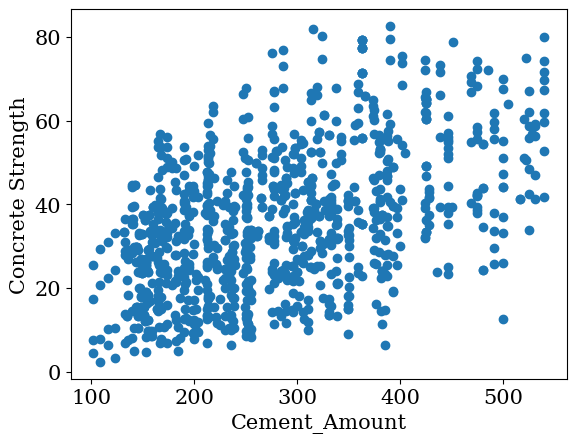

In [30]:
plt.scatter(x[:, 0], y[:, 0])
plt.xlabel('Cement_Amount')
plt.ylabel('Concrete Strength')

Text(0, 0.5, 'Concrete Strength')

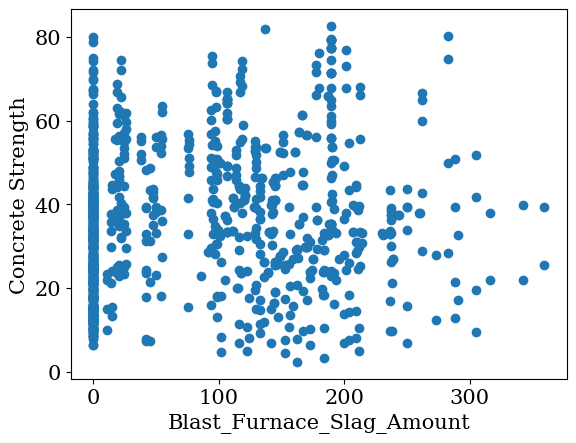

In [31]:
plt.scatter(x[:, 1], y[:, 0])
plt.xlabel('Blast_Furnace_Slag_Amount')
plt.ylabel('Concrete Strength')

Text(0, 0.5, 'Concrete Strength')

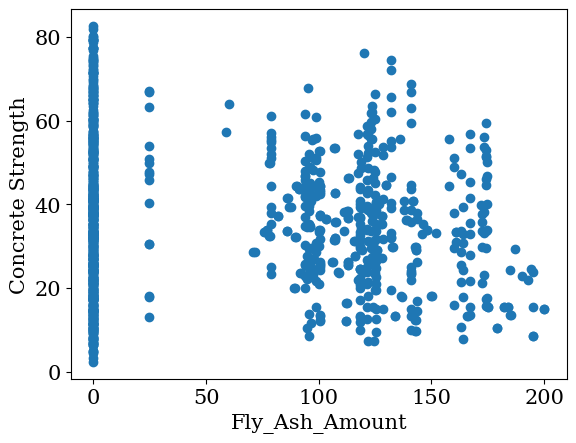

In [32]:
plt.scatter(x[:, 2], y[:, 0])
plt.xlabel('Fly_Ash_Amount')
plt.ylabel('Concrete Strength')

## Split the Dataset into Training and Testing

In [33]:
X_Train, X_Test, Y_Train, Y_Test = train_test_split(x, y, test_size = 1/3, random_state = 0)


# Fitting Simple Linear Regression to the training set

In [34]:
regressor = LinearRegression()
regressor.fit(X_Train, Y_Train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Coefficients

In [35]:
regressor.coef_, regressor.intercept_

(array([[0.12429187, 0.08808451, 0.09133734]]), array([-10.59158372]))

# Mean Squared Error on Training Data

In [36]:
import sklearn.metrics as sm
# error
Y_Pred = regressor.predict(X_Train)

e= sm.mean_squared_error(Y_Train, Y_Pred)
print("MSE = {}".format(e))

MSE = 169.9932577250444


# Mean Squared Error on Test Data

In [37]:
import sklearn.metrics as sm
# error
Y_Pred = regressor.predict(X_Test)
e= sm.mean_squared_error(Y_Test, Y_Pred)
print("MSE = {}".format(e))

MSE = 159.4968526436981


# L2 Regularization

In [38]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
ridgeModel = Lasso(alpha = 5)
ridgeModel.fit(X_Train, Y_Train)
ridgeModel.score(X_Test, Y_Test)

0.38617537093913956

# MSE on Training Set

In [39]:
import sklearn.metrics as sm
# error
Y_Pred = ridgeModel.predict(X_Train)

e= sm.mean_squared_error(Y_Train, Y_Pred)
print("MSE = {}".format(e))

MSE = 170.0278048523711


# MSE on Test Set

In [40]:
import sklearn.metrics as sm
# error
Y_Pred = ridgeModel.predict(X_Test)

e= sm.mean_squared_error(Y_Test, Y_Pred)
print("MSE = {}".format(e))

MSE = 159.38909203947816


# 3. Multiple Regression using StatsModel

In [42]:
import statsmodels.api as sm 
from sklearn.model_selection import train_test_split
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['font.size'] = 15

## Read the data

In [ ]:
df = pl.read_csv('https://raw.githubusercontent.com/rahulbhadani/Datasets/refs/heads/master/Advertising/Advertising.csv')
df.columns

['', 'TV', 'Radio', 'Newspaper', 'Sales']

In [48]:
df

,TV,Radio,Newspaper,Sales
i64,f64,f64,f64,f64
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
…,…,…,…,…
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8


The dataset contains TV Budget, Radio Budget and Newspaper Budget for an advertisement of a product at a company and Sales.

Our goal is to predict sales based on TV Budget, Radio Budget and Newspaper Budget

## Plot the Data


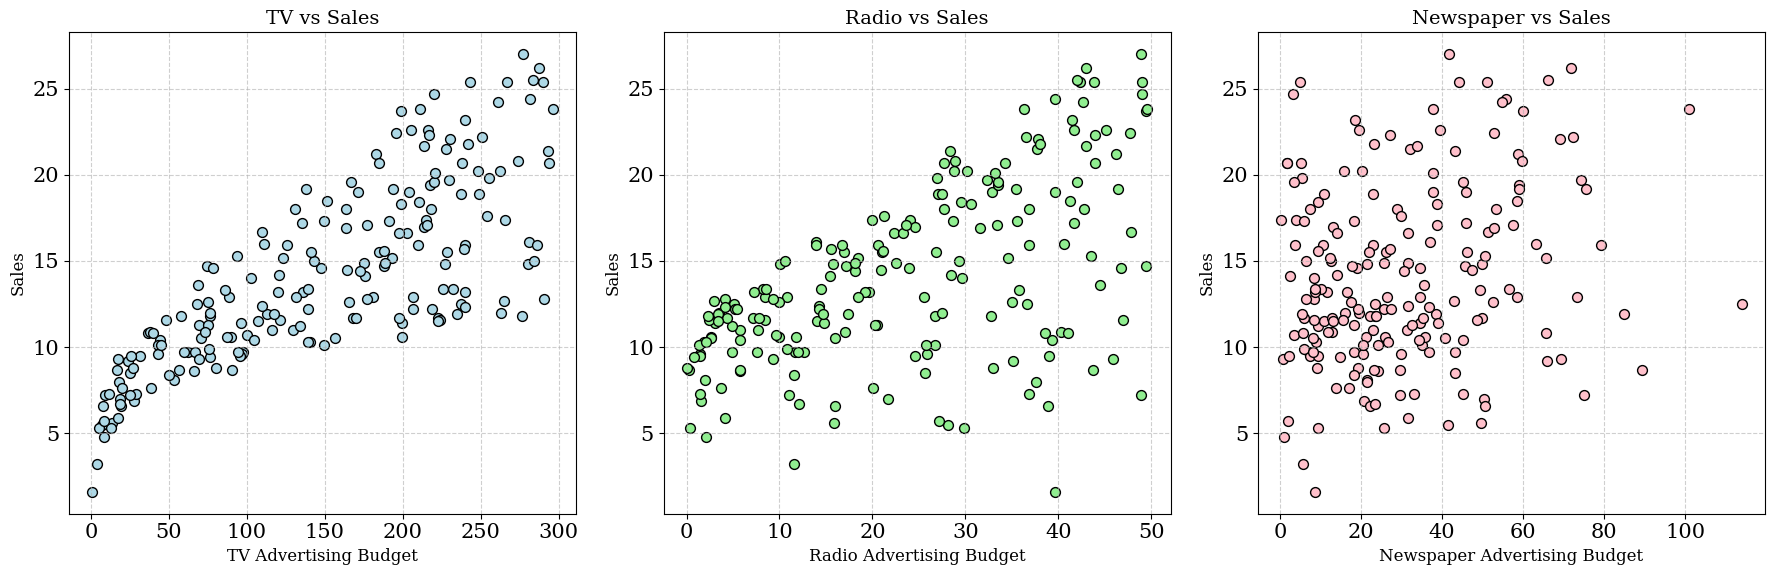

In [49]:
import matplotlib.pyplot as plt

# Create a figure with 1 row and 3 columns of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Adjust figsize for better visualization

# Define colors, marker size, and other properties
colors = ['blue', 'green', 'red']  # Different colors for each subplot
marker_size = 50  # Marker size
marker_edge_color = 'black'  # Edge color of markers
marker_face_colors = ['lightblue', 'lightgreen', 'pink']  # Face colors for markers

# Scatter plot for TV vs Sales
axes[0].scatter(df['TV'], df['Sales'], s=marker_size, c=marker_face_colors[0], 
                edgecolor=marker_edge_color, label='TV vs Sales')
axes[0].set_title('TV vs Sales', fontsize=14)
axes[0].set_xlabel('TV Advertising Budget', fontsize=12)
axes[0].set_ylabel('Sales', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Scatter plot for Radio vs Sales
axes[1].scatter(df['Radio'], df['Sales'], s=marker_size, c=marker_face_colors[1], 
                edgecolor=marker_edge_color, label='Radio vs Sales')
axes[1].set_title('Radio vs Sales', fontsize=14)
axes[1].set_xlabel('Radio Advertising Budget', fontsize=12)
axes[1].set_ylabel('Sales', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

# Scatter plot for Newspaper vs Sales
axes[2].scatter(df['Newspaper'], df['Sales'], s=marker_size, c=marker_face_colors[2], 
                edgecolor=marker_edge_color, label='Newspaper vs Sales')
axes[2].set_title('Newspaper vs Sales', fontsize=14)
axes[2].set_xlabel('Newspaper Advertising Budget', fontsize=12)
axes[2].set_ylabel('Sales', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.6)

# Add some spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

## Split the Dataset into Training and Testing

In [51]:
df_filtered = df.select(['TV', 'Radio', 'Newspaper'])
y = df.select(['Sales'])
# Separate features and labels
x = df_filtered.to_numpy().astype(np.float64)
y = y.to_numpy().reshape(-1, 1).astype(np.float64)

X_Train, X_Test, Y_Train, Y_Test = train_test_split(x, y, test_size = 1/3, random_state = 0)


## Fitting Simple Linear Regression to the training set

In [52]:
xt = sm.add_constant(X_Train) 
est = sm.OLS(Y_Train, xt).fit() 

## Print the Summary of the Result

In [53]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     418.1
Date:                Mon, 06 Oct 2025   Prob (F-statistic):           3.02e-66
Time:                        14:14:16   Log-Likelihood:                -250.83
No. Observations:                 133   AIC:                             509.7
Df Residuals:                     129   BIC:                             521.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9038      0.368      7.886      0.000       2.175       3.632
x1             0.0443      0.002     26.445      0.000       0.041       0.048
x2             0.1966      0.010     20.420      0.000       0.178       0.216
x3             0.0026      0.007      0.371      0.712      -0.011       0.017
==============================================================================
Omnibus:                       10.854   Durbin-Watson:                   2.117
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               11.895
Skew:                          -0.731   Prob(JB):                      0.00261
Kurtosis:                       2.909   Cond. No.                         462.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Summary
In the above result, we see that $R^2$ coefficient of determination was $0.907$,and estimated coefficients were $w_0 = 2.9038$, $w_1 = 0.0443	$, $w_2 = 0.1966$, and $w_3 = 0.0026$.
We can also see their respective 95% confidence interval as [2.175,	3.632], [0.041,	0.048], [0.178,	0.216], and [-0.011,	0.017].

Note: the answer might be different if rerun the notebook and training and test split will happen randomly everytime the whole notebook is run

If any feature has a high p-value (>0.05), it might not be contributing significantly to the prediction of Sales. Looking at P > |t|, we see that P-value is 0.712 for x3 which means Newspaper is not contributing significantly to sales

## Mean Squared Error on Training Dataset

In [54]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = est.predict(xt)
# Calculate the Mean Squared Error
mse = mean_squared_error(Y_Train.reshape(-1,), y_pred)
print(mse)

2.544737086192999


## Residual Analysis

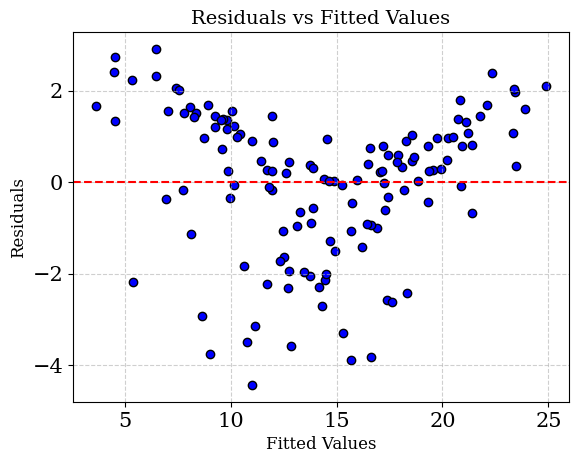

In [55]:
# Residuals on training data
residuals = Y_Train.reshape(-1,) - y_pred

# Plot residuals vs fitted values
plt.scatter(y_pred, residuals, color='blue', edgecolor='black')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values', fontsize=14)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

No funnel shaped residual, hence it doesn't violate the assumption of constant variance in linear regression.

## QQ Plot

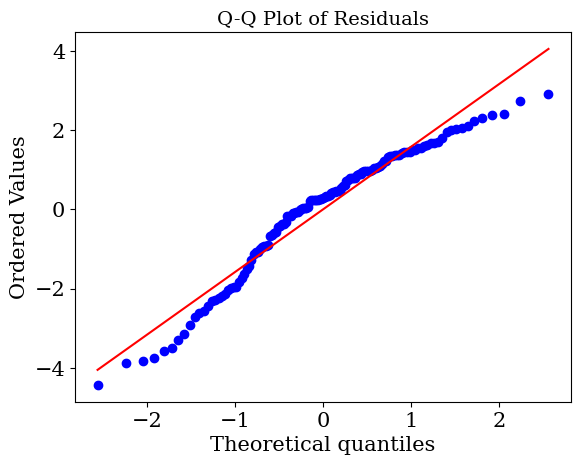

In [56]:
import scipy.stats as stats

# Q-Q plot for residuals
stats.probplot(residuals.ravel(), dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals', fontsize=14)
plt.show()

There doesn't seem strong deviation from normality of residuals assumptions

## Prediction on the test data

In [58]:
xtest = sm.add_constant(X_Test)

# Make a prediction
y_pred = est.predict(xtest)
print(y_pred)

[10.05097058  7.4499993   7.03252971 24.2016326  12.07738405  6.59463846
 13.1005242  15.00928045 11.03309254 16.2847153  23.03004114  9.15867999
 10.3813     15.4052521  11.59972016 12.11807438 18.61494072 10.7432436
 16.04872577 17.23807998 24.30021807  9.52267567 15.17507106 12.4525143
  5.72567004 15.19786664 12.25971506 20.91306214 13.3500593   9.18330769
 13.40551309 21.59403254 18.18162786 21.15410682  6.74539497  6.17340376
  8.01921503 13.19818262 14.77945892  6.2530578  12.3013568   9.14294205
 15.0344292  16.27684044 17.24700584 13.29967831  3.70063725 12.4796187
 15.94075082  8.75332029 10.66764063 19.62633967 18.42522765 15.28980862
 10.01254635  8.19179718 21.57005177 14.19260523 16.35109003  8.86081623
 15.34735514 12.37012562 13.72695688 14.18494574 18.40445716 19.29907579
 20.25742927]


## Mean Squared Error on test Dataset

In [59]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate the Mean Squared Error
mse = mean_squared_error(Y_Test, y_pred)
print(mse)

3.3864786054959786


## Feature Importance
Feature importance refers to techniques that calculate a score for all input features in a machine learning model. These scores represent how useful or valuable each feature is in predicting the target variable. Higher value means more important feature.

In [61]:
# Feature importance from Lasso
feature_importance = pl.DataFrame({
    'Feature': ['Constant', 'TV', 'Radio', 'Newspaper'],
    'Coefficient': est.params
})
print(feature_importance)

shape: (4, 2)
┌───────────┬─────────────┐
│ Feature   ┆ Coefficient │
│ ---       ┆ ---         │
│ str       ┆ f64         │
╞═══════════╪═════════════╡
│ Constant  ┆ 2.903765    │
│ TV        ┆ 0.044346    │
│ Radio     ┆ 0.196606    │
│ Newspaper ┆ 0.002626    │
└───────────┴─────────────┘


## Cross-validation MSE
In k-fold cross-validation , the dataset is divided into k subsets (folds). The model is trained on k−1 folds and tested on the remaining fold.
This process is repeated k times, with each fold serving as the test set once. The MSE is then averaged across all k iterations.

In [62]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# Using scikit-learn for cross-validation
lr = LinearRegression()
scores = cross_val_score(lr, x, y, cv=5, scoring='neg_mean_squared_error')
mse_scores = -scores
print(f"Cross-validated MSE: {mse_scores.mean()}")

Cross-validated MSE: 3.072946597100212


## L2 Regularization

In [63]:
# Apply Ridge (L2) regularization
ridge_model = sm.OLS(Y_Train, xt)
ridge_results = ridge_model.fit_regularized(method='elastic_net', alpha=10.0, L1_wt=0.0)  # L1_wt=0 for Ridge


# Predict on training and test data
y_train_pred_ridge = ridge_results.predict(xt)
y_test_pred_ridge = ridge_results.predict(sm.add_constant(X_Test))

# Calculate MSE for Ridge
mse_train_ridge = mean_squared_error(Y_Train, y_train_pred_ridge)
mse_test_ridge = mean_squared_error(Y_Test, y_test_pred_ridge)
print(f"Ridge Training MSE: {mse_train_ridge}")
print(f"Ridge Testing MSE: {mse_test_ridge}")

Ridge Training MSE: 3.750930961282048
Ridge Testing MSE: 4.584108976945223


## L1 Regularization

In [64]:
# Apply Lasso (L1) regularization
lasso_model = sm.OLS(Y_Train, xt)
lasso_results = lasso_model.fit_regularized(method='elastic_net', alpha=0.0, L1_wt=40.0)  # L1_wt=1 for Lasso

# Predict on training and test data
y_train_pred_lasso = lasso_results.predict(xt)
y_test_pred_lasso = lasso_results.predict(sm.add_constant(X_Test))

# Calculate MSE for Lasso
mse_train_lasso = mean_squared_error(Y_Train, y_train_pred_lasso)
mse_test_lasso = mean_squared_error(Y_Test, y_test_pred_lasso)
print(f"Lasso Training MSE: {mse_train_lasso}")
print(f"Lasso Testing MSE: {mse_test_lasso}")

Lasso Training MSE: 2.5447370866860823
Lasso Testing MSE: 3.3864658376808023


# 4.Implementation of Multiple Linear Regression Using PyTorch

## Method 1

## Load Dataset

In [ ]:
# Load the dataset
import torch
import polars as pl
df = pl.read_csv('https://raw.githubusercontent.com/rahulbhadani/Datasets/refs/heads/master/Advertising/Advertising.csv')

# Features and target
X = df.select(['TV', 'Radio', 'Newspaper']).to_numpy().astype(np.float32)
y = df['Sales'].to_numpy().astype(np.float32)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train).view(-1, 1)  # Reshape to column vector
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test).view(-1, 1)

## Define the model

In [67]:
# Initialize weights and bias
input_dim = X_train.shape[1]  # Number of features
W = torch.randn(input_dim, 1, requires_grad=True, dtype=torch.float32)  # Random initialization for weights
b = torch.randn(1, requires_grad=True, dtype=torch.float32)            # Random initialization for bias

# Define the linear regression model
def model(X):
    return X @ W + b  # Matrix multiplication: X @ W + b

## Define the Loss Function

In [68]:
# Define Mean Squared Error loss
def mse_loss(Y_pred, Y_true):
    return torch.mean((Y_pred - Y_true) ** 2)

## Training Procedure

In [69]:
# Hyperparameters
learning_rate = 0.00001
num_epochs = 1000000

# Training loop
for epoch in range(num_epochs):
    # Forward pass: Compute predictions
    Y_pred = model(X_train_tensor)

    # Compute loss
    loss = mse_loss(Y_pred, y_train_tensor)

    # Backward pass: Compute gradients
    loss.backward()

    # Update weights and bias manually
    with torch.no_grad():  # Disable gradient tracking during updates
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad

    # Zero gradients for the next iteration
    W.grad.zero_()
    b.grad.zero_()

    # Print progress every 100 epochs
    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1000/1000000], Loss: 3.0294
Epoch [2000/1000000], Loss: 3.0266
Epoch [3000/1000000], Loss: 3.0238
Epoch [4000/1000000], Loss: 3.0210
Epoch [5000/1000000], Loss: 3.0183
Epoch [6000/1000000], Loss: 3.0155
Epoch [7000/1000000], Loss: 3.0128
Epoch [8000/1000000], Loss: 3.0101
Epoch [9000/1000000], Loss: 3.0073
Epoch [10000/1000000], Loss: 3.0047
Epoch [11000/1000000], Loss: 3.0020
Epoch [12000/1000000], Loss: 2.9994
Epoch [13000/1000000], Loss: 2.9967
Epoch [14000/1000000], Loss: 2.9941
Epoch [15000/1000000], Loss: 2.9915
Epoch [16000/1000000], Loss: 2.9889
Epoch [17000/1000000], Loss: 2.9863
Epoch [18000/1000000], Loss: 2.9838
Epoch [19000/1000000], Loss: 2.9812
Epoch [20000/1000000], Loss: 2.9787
Epoch [21000/1000000], Loss: 2.9762
Epoch [22000/1000000], Loss: 2.9737
Epoch [23000/1000000], Loss: 2.9712
Epoch [24000/1000000], Loss: 2.9687
Epoch [25000/1000000], Loss: 2.9662
Epoch [26000/1000000], Loss: 2.9638
Epoch [27000/1000000], Loss: 2.9614
Epoch [28000/1000000], Loss: 2.9590
E

In [70]:
# Evaluate on test data
with torch.no_grad():  # Disable gradient computation
    Y_test_pred = model(X_test_tensor)
    test_loss = mse_loss(Y_test_pred, y_test_tensor)
    print(f'Test MSE: {test_loss.item():.4f}')

Test MSE: 3.3907


In [71]:
W, b

(tensor([[0.0446],
         [0.1978],
         [0.0033]], requires_grad=True),
 tensor([2.7994], requires_grad=True))

## Method 2

## Define the Model

In [72]:
import torch.nn as nn
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        # Initialize weights and bias
        self.weights = nn.Parameter(torch.randn(input_dim, 1))  # Random initialization
        self.bias = nn.Parameter(torch.randn(1))               # Random initialization

    def forward(self, x):
        # Perform matrix multiplication: y_pred = X @ W + b
        return x @ self.weights + self.bias

## Instantiate The Model

In [73]:
# Instantiate the model
input_dim = X_train.shape[1]  # Number of features
model = LinearRegressionModel(input_dim)

## Loss and Optimizer

In [74]:
# Define loss function
criterion = nn.MSELoss()

# Define optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.00001)

## Training 

In [75]:
# Training loop
num_epochs = 100000
for epoch in range(num_epochs):
    # Forward pass: Compute predictions
    y_pred = model(X_train_tensor)

    # Compute loss
    loss = criterion(y_pred, y_train_tensor)

    # Backward pass: Compute gradients
    optimizer.zero_grad()  # Clear previous gradients
    loss.backward()        # Compute gradients

    # Update parameters
    optimizer.step()

    # Print progress every 100 epochs
    if (epoch + 1) % 10000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10000/100000], Loss: 2.9487
Epoch [20000/100000], Loss: 2.9258
Epoch [30000/100000], Loss: 2.9043
Epoch [40000/100000], Loss: 2.8840
Epoch [50000/100000], Loss: 2.8648
Epoch [60000/100000], Loss: 2.8467
Epoch [70000/100000], Loss: 2.8297
Epoch [80000/100000], Loss: 2.8136
Epoch [90000/100000], Loss: 2.7984
Epoch [100000/100000], Loss: 2.7840


## Evaluation

In [76]:
# Evaluate on test data
with torch.no_grad():  # Disable gradient computation
    y_test_pred = model(X_test_tensor)
    test_loss = criterion(y_test_pred, y_test_tensor)
    print(f'Test MSE: {test_loss.item():.4f}')

Test MSE: 3.6607


## Assumptions

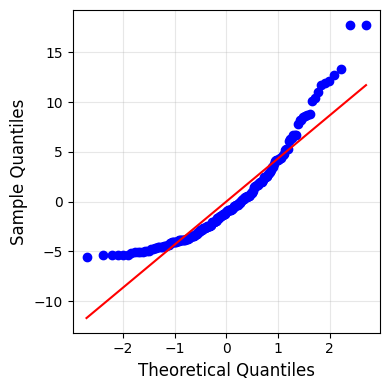

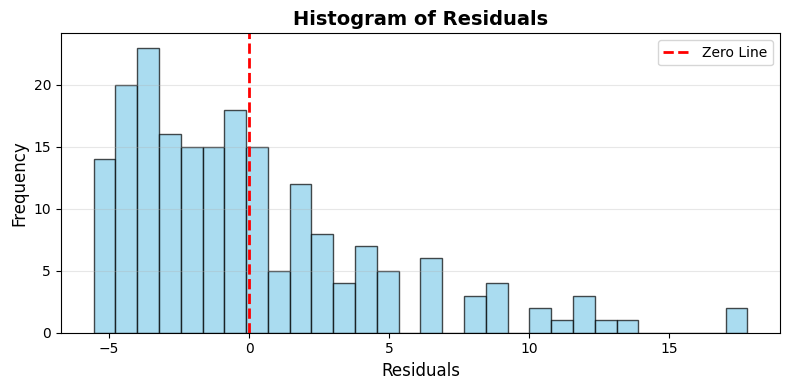

Shapiro-Wilk Test for Normality:
Statistic: 0.8798
P-value: 0.000000

Skewness: 1.3781
Kurtosis: 1.9408


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

# Generate data with non-normal residuals (exponential distribution)
n = 200
X = np.random.uniform(0, 10, n)

# Create a linear relationship with exponentially distributed errors (highly non-normal)
# Exponential distribution is heavily right-skewed
errors = np.random.exponential(scale=5, size=n) - 7  # Shift to center around 0
y = 2 + 3 * X + errors

# Fit linear regression
coefficients = np.polyfit(X, y, 1)
y_pred = coefficients[0] * X + coefficients[1]

# Calculate residuals
residuals = y - y_pred

# Create Q-Q plot
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('', fontsize=14, fontweight='bold')
ax.set_xlabel('Theoretical Quantiles', fontsize=12)
ax.set_ylabel('Sample Quantiles', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/extremeviolation_normality.pdf', format='pdf')

plt.show()
fig, ax = plt.subplots(1, 1, figsize=(8, 4))


# Histogram of residuals for comparison
ax.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax.set_title('Histogram of Residuals', fontsize=14, fontweight='bold')
ax.set_xlabel('Residuals', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Line')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print diagnostic statistics
print(f"Shapiro-Wilk Test for Normality:")
print(f"Statistic: {stats.shapiro(residuals)[0]:.4f}")
print(f"P-value: {stats.shapiro(residuals)[1]:.6f}")
print(f"\nSkewness: {stats.skew(residuals):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")

GRADIENT DESCENT ON CHAOTIC FUNCTION

Chaotic Function: f(x) = 3.9 * x² * (1-x)²
Initial value x₀ = 0.1
Learning rate α = 0.01


--- STEP 1 ---
Current position: x = 0.100000
Function value: f(x) = 0.031590
Gradient: f'(x) = 0.561600
Update: x_new = 0.100000 - 0.01 × 0.561600
        x_new = 0.094384

--- STEP 2 ---
Current position: x = 0.094384
Function value: f(x) = 0.028494
Gradient: f'(x) = 0.540857
Update: x_new = 0.094384 - 0.01 × 0.540857
        x_new = 0.088975

SUMMARY OF GRADIENT DESCENT TRAJECTORY
Step   x            f(x)         f'(x)       
----------------------------------------------------------------------
0      0.100000     0.031590     0.561600    
1      0.094384     0.028494     0.540857    
2      0.088975     0.025625     0.519748    


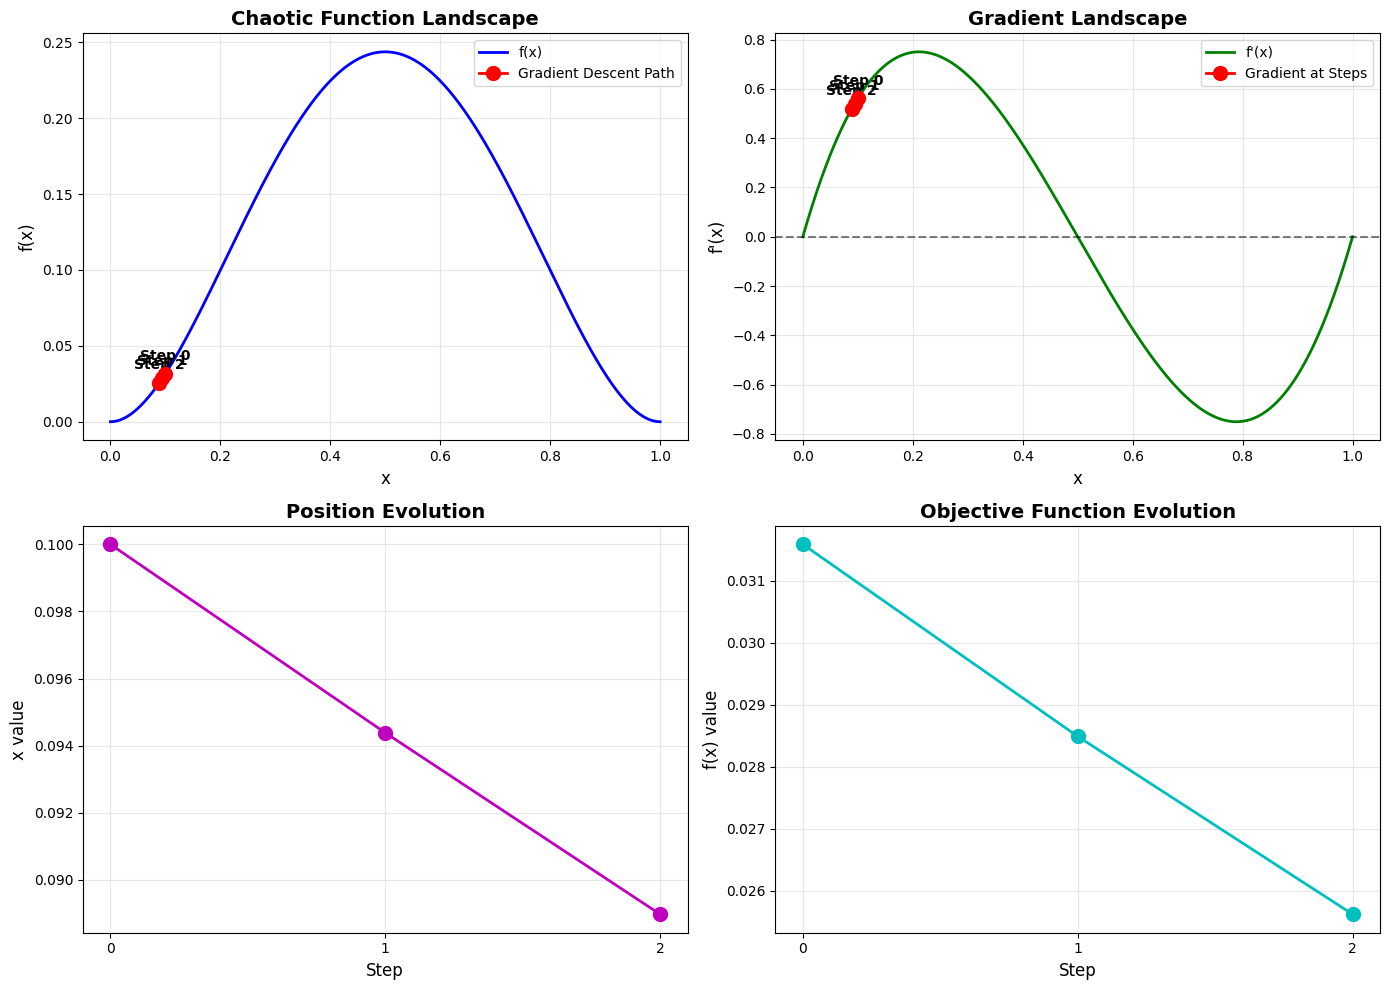


ANALYSIS
Total change in x: -0.011025
Total change in f(x): -0.005965
Direction: Decreasing ✓

Note: The chaotic nature creates a complex landscape with
multiple local minima, making optimization challenging!


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Define a chaotic function: the logistic map modified for optimization
# f(x) = r * x * (1 - x) where r controls chaos (we'll use r=3.9 for chaotic behavior)
# For gradient descent, we'll minimize: L(x) = -f(x) or use f(x) = r * x^2 * (1 - x)^2

def chaotic_function(x, r=3.9):
    """
    Chaotic function based on logistic map
    f(x) = r * x^2 * (1 - x)^2
    This creates a complex landscape with multiple local minima
    """
    return r * (x**2) * ((1 - x)**2)

def gradient_chaotic(x, r=3.9):
    """
    Gradient of the chaotic function
    f'(x) = r * [2x(1-x)^2 + x^2 * 2(1-x)(-1)]
          = r * [2x(1-x)^2 - 2x^2(1-x)]
          = 2rx(1-x)[(1-x) - x]
          = 2rx(1-x)(1-2x)
    """
    return 2 * r * x * (1 - x) * (1 - 2*x)

# Parameters
x0 = 0.1  # Initial value
learning_rate = 0.01
r = 3.9  # Chaos parameter

print("=" * 70)
print("GRADIENT DESCENT ON CHAOTIC FUNCTION")
print("=" * 70)
print(f"\nChaotic Function: f(x) = {r} * x² * (1-x)²")
print(f"Initial value x₀ = {x0}")
print(f"Learning rate α = {learning_rate}")
print("\n" + "=" * 70)

# Store trajectory
x_values = [x0]
f_values = [chaotic_function(x0, r)]
grad_values = [gradient_chaotic(x0, r)]

# Perform two steps of gradient descent
x_current = x0

for step in range(1, 3):
    print(f"\n--- STEP {step} ---")
    
    # Calculate gradient at current point
    grad = gradient_chaotic(x_current, r)
    print(f"Current position: x = {x_current:.6f}")
    print(f"Function value: f(x) = {chaotic_function(x_current, r):.6f}")
    print(f"Gradient: f'(x) = {grad:.6f}")
    
    # Update using gradient descent: x_new = x_old - α * gradient
    x_new = x_current - learning_rate * grad
    
    print(f"Update: x_new = {x_current:.6f} - {learning_rate} × {grad:.6f}")
    print(f"        x_new = {x_new:.6f}")
    
    # Store values
    x_values.append(x_new)
    f_values.append(chaotic_function(x_new, r))
    grad_values.append(gradient_chaotic(x_new, r))
    
    # Update current position
    x_current = x_new

print("\n" + "=" * 70)
print("SUMMARY OF GRADIENT DESCENT TRAJECTORY")
print("=" * 70)
print(f"{'Step':<6} {'x':<12} {'f(x)':<12} {'f\'(x)':<12}")
print("-" * 70)
for i, (x, f, g) in enumerate(zip(x_values, f_values, grad_values)):
    print(f"{i:<6} {x:<12.6f} {f:<12.6f} {g:<12.6f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Function landscape
x_plot = np.linspace(0, 1, 1000)
y_plot = chaotic_function(x_plot, r)

axes[0, 0].plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
axes[0, 0].plot(x_values, f_values, 'ro-', markersize=10, linewidth=2, 
                label='Gradient Descent Path', zorder=5)
for i, (x, y) in enumerate(zip(x_values, f_values)):
    axes[0, 0].annotate(f'Step {i}', (x, y), textcoords="offset points", 
                       xytext=(0,10), ha='center', fontsize=10, fontweight='bold')
axes[0, 0].set_xlabel('x', fontsize=12)
axes[0, 0].set_ylabel('f(x)', fontsize=12)
axes[0, 0].set_title('Chaotic Function Landscape', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Gradient landscape
grad_plot = gradient_chaotic(x_plot, r)
axes[0, 1].plot(x_plot, grad_plot, 'g-', linewidth=2, label="f'(x)")
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0, 1].plot(x_values, grad_values, 'ro-', markersize=10, linewidth=2, 
                label='Gradient at Steps', zorder=5)
for i, (x, g) in enumerate(zip(x_values, grad_values)):
    axes[0, 1].annotate(f'Step {i}', (x, g), textcoords="offset points", 
                       xytext=(0,10), ha='center', fontsize=10, fontweight='bold')
axes[0, 1].set_xlabel('x', fontsize=12)
axes[0, 1].set_ylabel("f'(x)", fontsize=12)
axes[0, 1].set_title('Gradient Landscape', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Trajectory in x-space
axes[1, 0].plot(range(len(x_values)), x_values, 'mo-', markersize=10, linewidth=2)
axes[1, 0].set_xlabel('Step', fontsize=12)
axes[1, 0].set_ylabel('x value', fontsize=12)
axes[1, 0].set_title('Position Evolution', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(range(len(x_values)))

# Plot 4: Function value evolution
axes[1, 1].plot(range(len(f_values)), f_values, 'co-', markersize=10, linewidth=2)
axes[1, 1].set_xlabel('Step', fontsize=12)
axes[1, 1].set_ylabel('f(x) value', fontsize=12)
axes[1, 1].set_title('Objective Function Evolution', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(range(len(f_values)))

plt.tight_layout()
plt.show()

# Additional analysis
print("\n" + "=" * 70)
print("ANALYSIS")
print("=" * 70)
print(f"Total change in x: {x_values[-1] - x_values[0]:.6f}")
print(f"Total change in f(x): {f_values[-1] - f_values[0]:.6f}")
print(f"Direction: {'Decreasing ✓' if f_values[-1] < f_values[0] else 'Increasing'}")
print(f"\nNote: The chaotic nature creates a complex landscape with")
print(f"multiple local minima, making optimization challenging!")

REGRESSION DIAGNOSTICS PROBLEM SET

### DATASET 1: Multicollinearity ###

Variance Inflation Factors (VIF):
  Feature          VIF
0      X1  2630.409715
1      X2  1534.629077
2      X3   293.424349
3      X4    13.290052
4      X5    11.975159
5      X6  2491.481593

Interpretation:
VIF > 10: Severe multicollinearity
VIF 5-10: Moderate multicollinearity
VIF < 5: Low multicollinearity


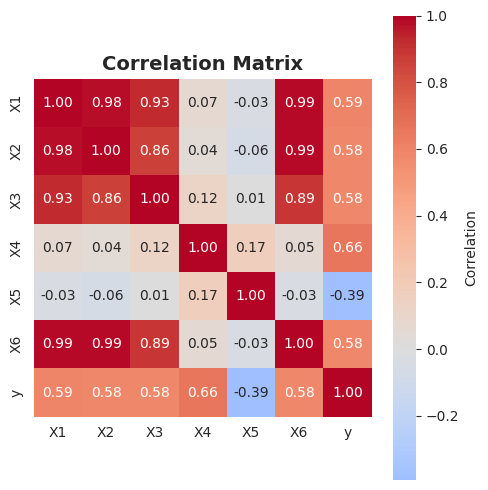

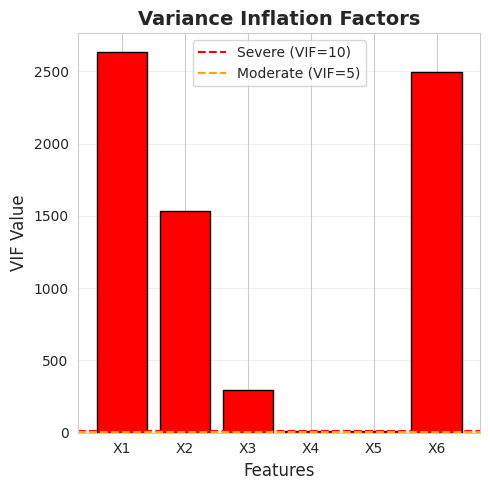


### DATASET 2: Heteroscedasticity ###



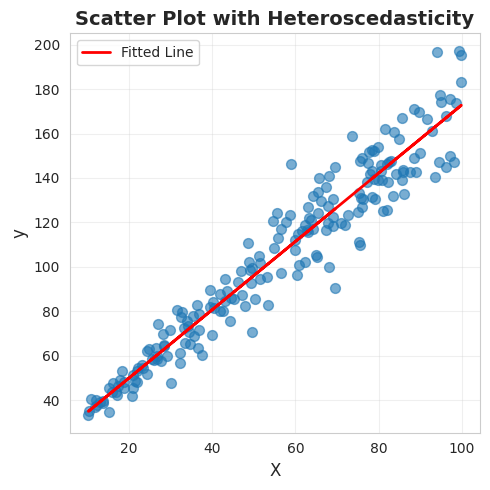

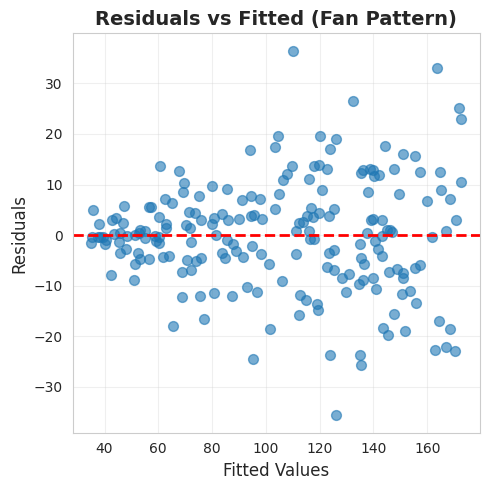

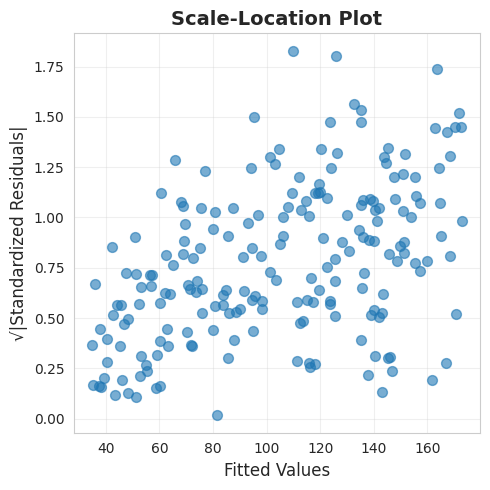

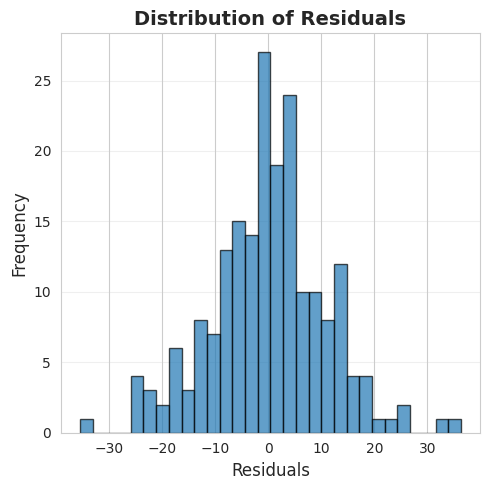

Breusch-Pagan test would be appropriate here to test for heteroscedasticity

### DATASET 3: Non-Normality of Residuals ###

Shapiro-Wilk Test: W=0.8695, p-value=0.000000


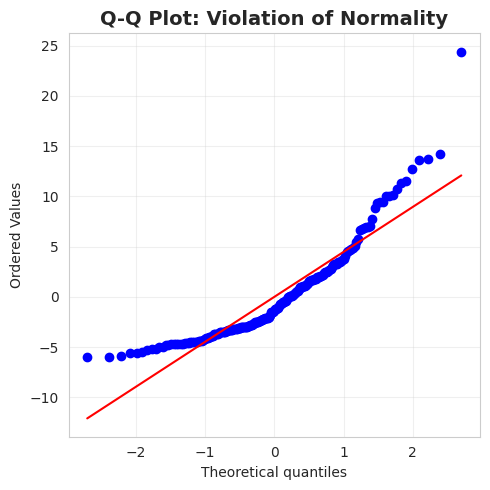

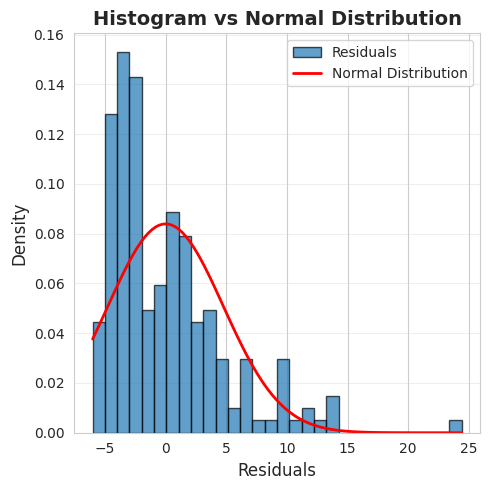

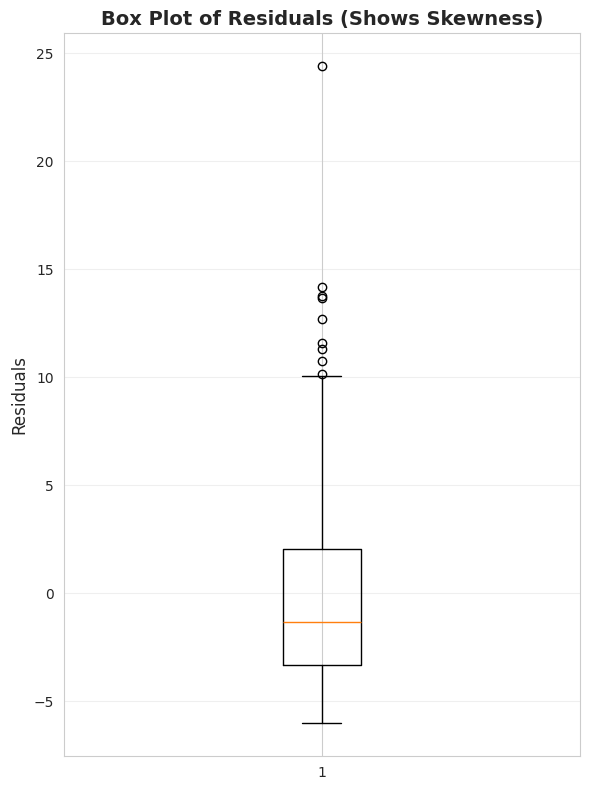

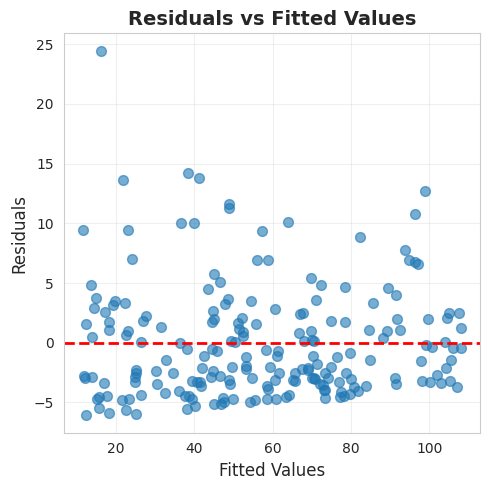

Skewness: 1.5554
Kurtosis: 3.3607

### DATASET 4: Non-Linearity ###



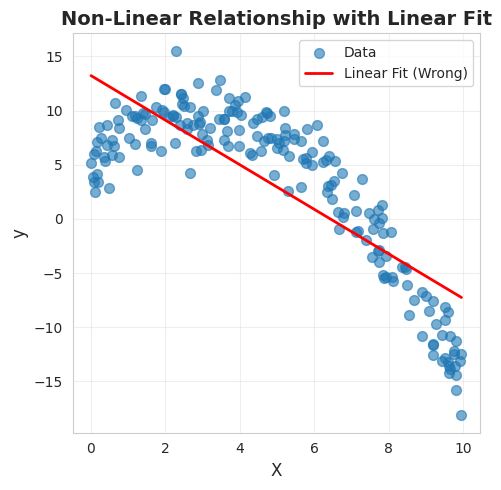

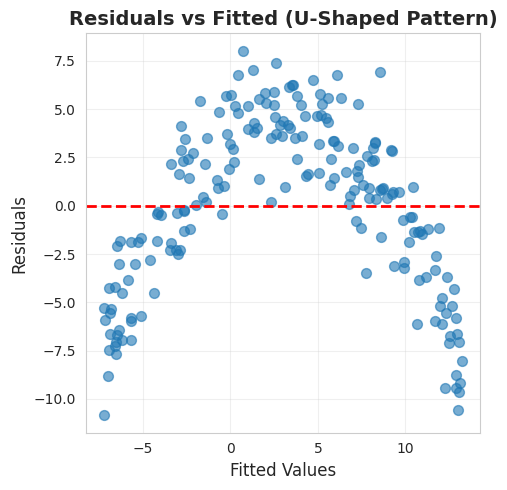

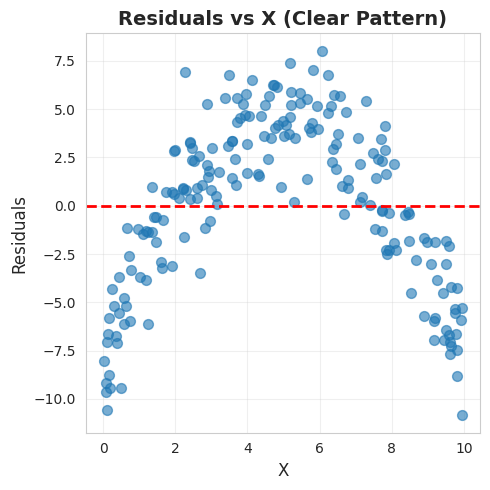

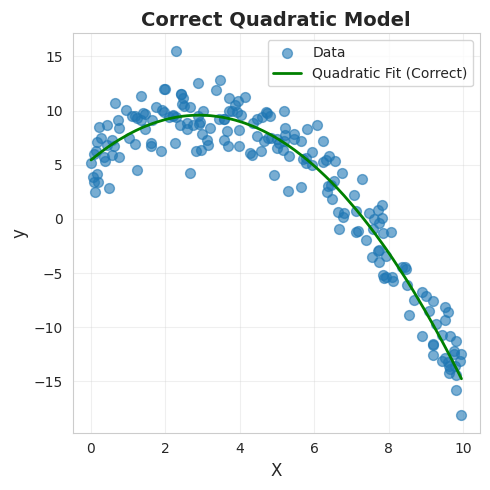


### DATASET 5: Outliers and Influential Points ###



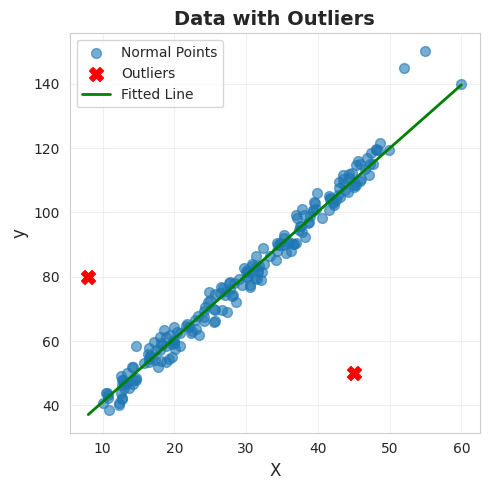

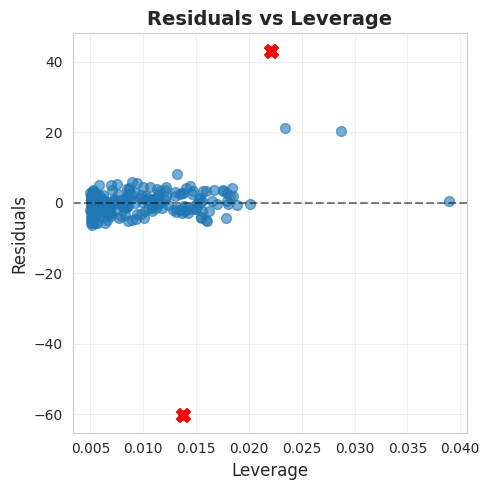

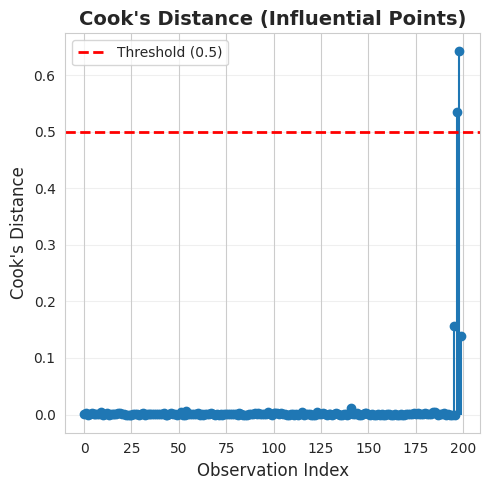

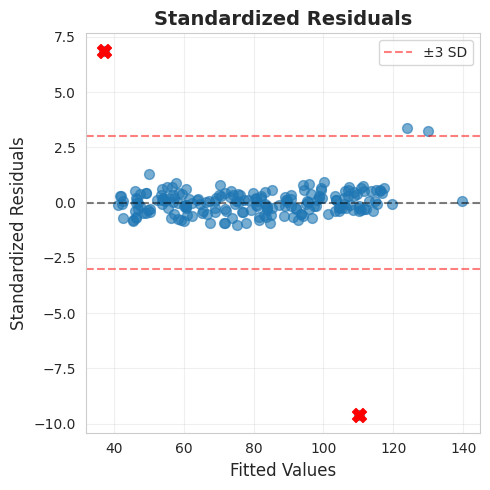

Number of influential points (Cook's D > 0.5): 2

### DATASET 6: Autocorrelation in Residuals ###



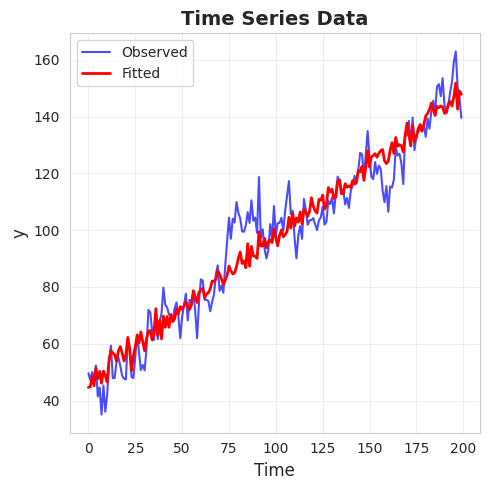

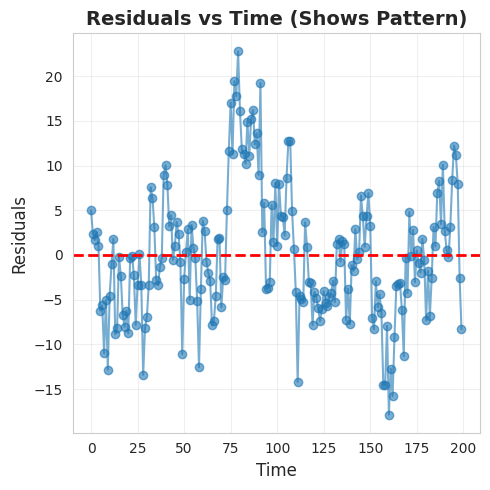

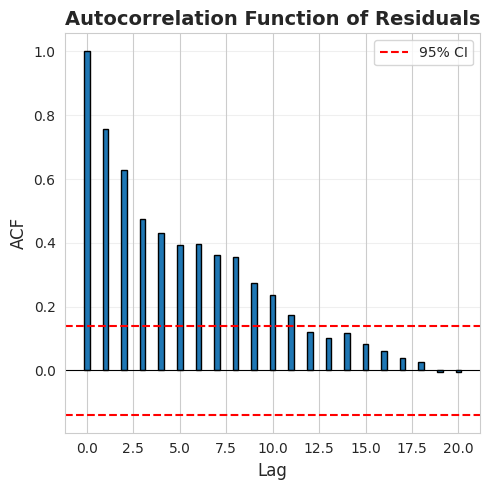

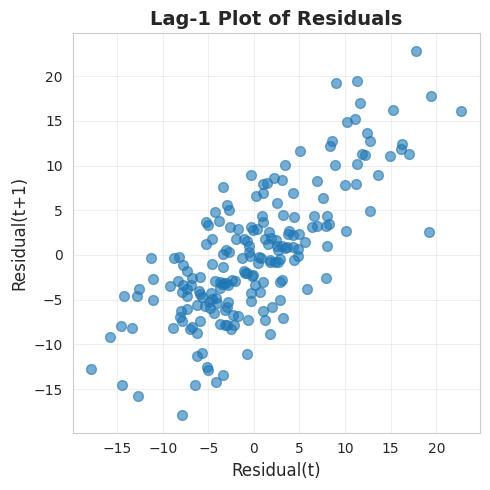

Durbin-Watson Statistic: 0.4861
Interpretation: DW ≈ 2 suggests no autocorrelation
               DW < 2 suggests positive autocorrelation
               DW > 2 suggests negative autocorrelation

ALL FIGURES SAVED TO 'figures/' FOLDER AS PDF FILES

Total figures generated: 24

Dataset 1 - Multicollinearity: 2 figures
Dataset 2 - Heteroscedasticity: 4 figures
Dataset 3 - Non-Normality: 4 figures
Dataset 4 - Non-Linearity: 4 figures
Dataset 5 - Outliers: 4 figures
Dataset 6 - Autocorrelation: 4 figures

ASSESSMENT QUESTIONS FOR STUDENTS

1. MULTICOLLINEARITY:
   - Which features show high multicollinearity?
   - What is the VIF threshold for concern?
   - How would you address multicollinearity?

2. HETEROSCEDASTICITY:
   - Describe the pattern in the residuals vs fitted plot
   - What transformation might fix heteroscedasticity?
   - How does it violate OLS assumptions?

3. NON-NORMALITY:
   - Is the Q-Q plot linear? What does this indicate?
   - What is the p-value from Shapiro-Wilk te

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os

# Create figures directory if it doesn't exist
os.makedirs('figures', exist_ok=True)

# Set style
sns.set_style("whitegrid")
np.random.seed(42)

# Generate sample size
n = 200

print("="*80)
print("REGRESSION DIAGNOSTICS PROBLEM SET")
print("="*80)

# =============================================================================
# DATASET 1: MULTICOLLINEARITY DEMONSTRATION
# =============================================================================
print("\n### DATASET 1: Multicollinearity ###\n")

# Generate highly correlated features
X1 = np.random.normal(50, 10, n)
X2 = X1 + np.random.normal(0, 2, n)  # Highly correlated with X1
X3 = 2*X1 - X2 + np.random.normal(0, 3, n)  # Linear combination
X4 = np.random.normal(30, 8, n)  # Independent
X5 = np.random.normal(40, 12, n)  # Independent
X6 = 0.5*X1 + 0.5*X2 + np.random.normal(0, 1, n)  # Correlated with X1 and X2

# Generate target with normal errors
y1 = 5 + 2*X1 + 3*X4 - 1.5*X5 + np.random.normal(0, 5, n)

# Create dataframe
df1 = pd.DataFrame({
    'X1': X1, 'X2': X2, 'X3': X3, 'X4': X4, 'X5': X5, 'X6': X6, 'y': y1
})

# Calculate correlation matrix
corr_matrix = df1.corr()

# Calculate VIF
X_multi = df1[['X1', 'X2', 'X3', 'X4', 'X5', 'X6']].values
vif_data = pd.DataFrame()
vif_data["Feature"] = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
vif_data["VIF"] = [variance_inflation_factor(X_multi, i) for i in range(X_multi.shape[1])]

print("Variance Inflation Factors (VIF):")
print(vif_data)
print("\nInterpretation:")
print("VIF > 10: Severe multicollinearity")
print("VIF 5-10: Moderate multicollinearity")
print("VIF < 5: Low multicollinearity")

# Plot 1a: Correlation heatmap
fig = plt.figure(figsize=(5, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/plot1a_correlation_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 1b: VIF bar plot
fig = plt.figure(figsize=(5, 5))
colors = ['red' if v > 10 else 'orange' if v > 5 else 'green' for v in vif_data['VIF']]
plt.bar(vif_data['Feature'], vif_data['VIF'], color=colors, edgecolor='black')
plt.axhline(y=10, color='red', linestyle='--', label='Severe (VIF=10)')
plt.axhline(y=5, color='orange', linestyle='--', label='Moderate (VIF=5)')
plt.ylabel('VIF Value', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.title('Variance Inflation Factors', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot1b_vif_barplot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# DATASET 2: HETEROSCEDASTICITY
# =============================================================================
print("\n### DATASET 2: Heteroscedasticity ###\n")

X_hetero = np.random.uniform(10, 100, n)
# Error variance increases with X (fan shape)
errors_hetero = np.random.normal(0, X_hetero/5, n)
y_hetero = 20 + 1.5*X_hetero + errors_hetero

# Fit model
model_hetero = LinearRegression()
model_hetero.fit(X_hetero.reshape(-1, 1), y_hetero)
y_pred_hetero = model_hetero.predict(X_hetero.reshape(-1, 1))
residuals_hetero = y_hetero - y_pred_hetero

# Plot 2a: Scatter plot with regression line
fig = plt.figure(figsize=(5, 5))
plt.scatter(X_hetero, y_hetero, alpha=0.6, s=50)
plt.plot(X_hetero, y_pred_hetero, 'r-', linewidth=2, label='Fitted Line')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Scatter Plot with Heteroscedasticity', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot2a_scatter_heteroscedasticity.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2b: Residuals vs Fitted
fig = plt.figure(figsize=(5, 5))
plt.scatter(y_pred_hetero, residuals_hetero, alpha=0.6, s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Fitted (Fan Pattern)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot2b_residuals_vs_fitted.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2c: Scale-Location plot
fig = plt.figure(figsize=(5, 5))
standardized_residuals = residuals_hetero / np.std(residuals_hetero)
plt.scatter(y_pred_hetero, np.sqrt(np.abs(standardized_residuals)), alpha=0.6, s=50)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('√|Standardized Residuals|', fontsize=12)
plt.title('Scale-Location Plot', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot2c_scale_location.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2d: Histogram of residuals
fig = plt.figure(figsize=(5, 5))
plt.hist(residuals_hetero, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot2d_residuals_histogram.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Breusch-Pagan test would be appropriate here to test for heteroscedasticity")

# =============================================================================
# DATASET 3: NON-NORMALITY OF RESIDUALS
# =============================================================================
print("\n### DATASET 3: Non-Normality of Residuals ###\n")

X_normal = np.random.uniform(0, 50, n)
# Generate non-normal errors (exponential distribution - right skewed)
errors_nonnormal = np.random.exponential(scale=5, size=n) - 5
y_nonnormal = 10 + 2*X_normal + errors_nonnormal

# Fit model
model_nonnormal = LinearRegression()
model_nonnormal.fit(X_normal.reshape(-1, 1), y_nonnormal)
y_pred_nonnormal = model_nonnormal.predict(X_normal.reshape(-1, 1))
residuals_nonnormal = y_nonnormal - y_pred_nonnormal

# Shapiro-Wilk test
shapiro_stat, shapiro_pval = stats.shapiro(residuals_nonnormal)
print(f"Shapiro-Wilk Test: W={shapiro_stat:.4f}, p-value={shapiro_pval:.6f}")

# Plot 3a: Q-Q Plot
fig = plt.figure(figsize=(5, 5))
stats.probplot(residuals_nonnormal, dist="norm", plot=plt)
plt.title('Q-Q Plot: Violation of Normality', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot3a_qq_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3b: Histogram with normal curve overlay
fig = plt.figure(figsize=(5, 5))
plt.hist(residuals_nonnormal, bins=30, density=True, 
         edgecolor='black', alpha=0.7, label='Residuals')
mu, sigma = residuals_nonnormal.mean(), residuals_nonnormal.std()
x_norm = np.linspace(residuals_nonnormal.min(), residuals_nonnormal.max(), 100)
plt.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 
         'r-', linewidth=2, label='Normal Distribution')
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Histogram vs Normal Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot3b_histogram_vs_normal.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3c: Box plot
fig = plt.figure(figsize=(6, 8))
plt.boxplot(residuals_nonnormal, vert=True)
plt.ylabel('Residuals', fontsize=12)
plt.title('Box Plot of Residuals (Shows Skewness)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot3c_boxplot_residuals.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 3d: Residuals vs Fitted
fig = plt.figure(figsize=(5, 5))
plt.scatter(y_pred_nonnormal, residuals_nonnormal, alpha=0.6, s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Fitted Values', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot3d_residuals_vs_fitted_nonnormal.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Skewness: {stats.skew(residuals_nonnormal):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals_nonnormal):.4f}")

# =============================================================================
# DATASET 4: NON-LINEARITY
# =============================================================================
print("\n### DATASET 4: Non-Linearity ###\n")

X_nonlinear = np.random.uniform(0, 10, n)
# True relationship is quadratic
y_nonlinear = 5 + 3*X_nonlinear - 0.5*X_nonlinear**2 + np.random.normal(0, 2, n)

# Fit linear model (incorrect)
model_nonlinear = LinearRegression()
model_nonlinear.fit(X_nonlinear.reshape(-1, 1), y_nonlinear)
y_pred_nonlinear = model_nonlinear.predict(X_nonlinear.reshape(-1, 1))
residuals_nonlinear = y_nonlinear - y_pred_nonlinear

# Plot 4a: Scatter with linear fit
fig = plt.figure(figsize=(5, 5))
sorted_idx = np.argsort(X_nonlinear)
plt.scatter(X_nonlinear, y_nonlinear, alpha=0.6, s=50, label='Data')
plt.plot(X_nonlinear[sorted_idx], y_pred_nonlinear[sorted_idx], 
         'r-', linewidth=2, label='Linear Fit (Wrong)')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Non-Linear Relationship with Linear Fit', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot4a_nonlinear_data_linear_fit.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4b: Residuals vs Fitted (shows pattern)
fig = plt.figure(figsize=(5, 5))
plt.scatter(y_pred_nonlinear, residuals_nonlinear, alpha=0.6, s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Fitted (U-Shaped Pattern)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot4b_residuals_vs_fitted_ushaped.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4c: Residuals vs X
fig = plt.figure(figsize=(5, 5))
plt.scatter(X_nonlinear, residuals_nonlinear, alpha=0.6, s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('X', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs X (Clear Pattern)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot4c_residuals_vs_x.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 4d: Comparison with correct quadratic fit
fig = plt.figure(figsize=(5, 5))
X_quad = np.column_stack([X_nonlinear, X_nonlinear**2])
model_quad = LinearRegression()
model_quad.fit(X_quad, y_nonlinear)
y_pred_quad = model_quad.predict(X_quad)
plt.scatter(X_nonlinear, y_nonlinear, alpha=0.6, s=50, label='Data')
plt.plot(X_nonlinear[sorted_idx], y_pred_quad[sorted_idx], 
         'g-', linewidth=2, label='Quadratic Fit (Correct)')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Correct Quadratic Model', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot4d_quadratic_fit.pdf', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# DATASET 5: OUTLIERS AND INFLUENTIAL POINTS
# =============================================================================
print("\n### DATASET 5: Outliers and Influential Points ###\n")

X_outlier = np.random.uniform(10, 50, n-5)
y_outlier = 20 + 2*X_outlier + np.random.normal(0, 3, n-5)

# Add outliers
X_outlier = np.append(X_outlier, [55, 60, 8, 45, 52])
y_outlier = np.append(y_outlier, [150, 140, 80, 50, 145])

# Fit model with outliers
model_outlier = LinearRegression()
model_outlier.fit(X_outlier.reshape(-1, 1), y_outlier)
y_pred_outlier = model_outlier.predict(X_outlier.reshape(-1, 1))
residuals_outlier = y_outlier - y_pred_outlier

# Calculate leverage and Cook's distance
X_with_intercept = np.column_stack([np.ones(len(X_outlier)), X_outlier])
hat_matrix = X_with_intercept @ np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T
leverage = np.diag(hat_matrix)

# Cook's distance
mse = np.sum(residuals_outlier**2) / (len(residuals_outlier) - 2)
cooks_d = (residuals_outlier**2 / (2 * mse)) * (leverage / (1 - leverage)**2)

outlier_mask = cooks_d > 0.5

# Plot 5a: Scatter plot with outliers highlighted
fig = plt.figure(figsize=(5, 5))
plt.scatter(X_outlier[~outlier_mask], y_outlier[~outlier_mask], 
            alpha=0.6, s=50, label='Normal Points')
plt.scatter(X_outlier[outlier_mask], y_outlier[outlier_mask], 
            color='red', s=100, label='Outliers', marker='X')
sorted_idx = np.argsort(X_outlier)
plt.plot(X_outlier[sorted_idx], y_pred_outlier[sorted_idx], 
         'g-', linewidth=2, label='Fitted Line')
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Data with Outliers', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot5a_data_with_outliers.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 5b: Residuals vs Leverage
fig = plt.figure(figsize=(5, 5))
plt.scatter(leverage, residuals_outlier, alpha=0.6, s=50)
plt.scatter(leverage[outlier_mask], residuals_outlier[outlier_mask], 
            color='red', s=100, marker='X')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Leverage', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Leverage', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot5b_residuals_vs_leverage.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 5c: Cook's distance plot
fig = plt.figure(figsize=(5, 5))
plt.stem(range(len(cooks_d)), cooks_d, basefmt=" ")
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')
plt.xlabel('Observation Index', fontsize=12)
plt.ylabel("Cook's Distance", fontsize=12)
plt.title("Cook's Distance (Influential Points)", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot5c_cooks_distance.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 5d: Standardized residuals
fig = plt.figure(figsize=(5, 5))
standardized_res = residuals_outlier / np.std(residuals_outlier)
plt.scatter(y_pred_outlier, standardized_res, alpha=0.6, s=50)
plt.scatter(y_pred_outlier[outlier_mask], standardized_res[outlier_mask], 
            color='red', s=100, marker='X')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='±3 SD')
plt.axhline(y=-3, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('Standardized Residuals', fontsize=12)
plt.title('Standardized Residuals', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot5d_standardized_residuals.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Number of influential points (Cook's D > 0.5): {np.sum(cooks_d > 0.5)}")

# =============================================================================
# DATASET 6: AUTOCORRELATION (Time Series)
# =============================================================================
print("\n### DATASET 6: Autocorrelation in Residuals ###\n")

t = np.arange(n)
X_time = t + np.random.normal(0, 5, n)

# Generate autocorrelated errors (AR(1) process)
errors_auto = np.zeros(n)
errors_auto[0] = np.random.normal(0, 1)
rho = 0.8  # Autocorrelation coefficient
for i in range(1, n):
    errors_auto[i] = rho * errors_auto[i-1] + np.random.normal(0, 1)

y_time = 50 + 0.5*X_time + errors_auto * 5

# Fit model
model_time = LinearRegression()
model_time.fit(X_time.reshape(-1, 1), y_time)
y_pred_time = model_time.predict(X_time.reshape(-1, 1))
residuals_time = y_time - y_pred_time

# Durbin-Watson statistic (approximately)
dw_stat = np.sum(np.diff(residuals_time)**2) / np.sum(residuals_time**2)

# Plot 6a: Time series plot
fig = plt.figure(figsize=(5, 5))
plt.plot(t, y_time, 'b-', alpha=0.7, label='Observed')
plt.plot(t, y_pred_time, 'r-', linewidth=2, label='Fitted')
plt.xlabel('Time', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Time Series Data', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot6a_timeseries_data.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 6b: Residuals over time
fig = plt.figure(figsize=(5, 5))
plt.plot(t, residuals_time, 'o-', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Time (Shows Pattern)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot6b_residuals_vs_time.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 6c: ACF plot
fig = plt.figure(figsize=(5, 5))
max_lag = 20
acf = [1.0]
for lag in range(1, max_lag + 1):
    correlation = np.corrcoef(residuals_time[:-lag], residuals_time[lag:])[0, 1]
    acf.append(correlation)
plt.bar(range(len(acf)), acf, width=0.3, edgecolor='black')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.axhline(y=1.96/np.sqrt(n), color='red', linestyle='--', label='95% CI')
plt.axhline(y=-1.96/np.sqrt(n), color='red', linestyle='--')
plt.xlabel('Lag', fontsize=12)
plt.ylabel('ACF', fontsize=12)
plt.title('Autocorrelation Function of Residuals', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot6c_acf_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot 6d: Lag plot
fig = plt.figure(figsize=(5, 5))
plt.scatter(residuals_time[:-1], residuals_time[1:], alpha=0.6, s=50)
plt.xlabel('Residual(t)', fontsize=12)
plt.ylabel('Residual(t+1)', fontsize=12)
plt.title('Lag-1 Plot of Residuals', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/plot6d_lag_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Durbin-Watson Statistic: {dw_stat:.4f}")
print("Interpretation: DW ≈ 2 suggests no autocorrelation")
print("               DW < 2 suggests positive autocorrelation")
print("               DW > 2 suggests negative autocorrelation")

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "="*80)
print("ALL FIGURES SAVED TO 'figures/' FOLDER AS PDF FILES")
print("="*80)
print("\nTotal figures generated: 24")
print("\nDataset 1 - Multicollinearity: 2 figures")
print("Dataset 2 - Heteroscedasticity: 4 figures")
print("Dataset 3 - Non-Normality: 4 figures")
print("Dataset 4 - Non-Linearity: 4 figures")
print("Dataset 5 - Outliers: 4 figures")
print("Dataset 6 - Autocorrelation: 4 figures")

print("\n" + "="*80)
print("ASSESSMENT QUESTIONS FOR STUDENTS")
print("="*80)
print("""
1. MULTICOLLINEARITY:
   - Which features show high multicollinearity?
   - What is the VIF threshold for concern?
   - How would you address multicollinearity?

2. HETEROSCEDASTICITY:
   - Describe the pattern in the residuals vs fitted plot
   - What transformation might fix heteroscedasticity?
   - How does it violate OLS assumptions?

3. NON-NORMALITY:
   - Is the Q-Q plot linear? What does this indicate?
   - What is the p-value from Shapiro-Wilk test?
   - Does non-normality affect coefficient estimates?

4. NON-LINEARITY:
   - What pattern do you see in residuals vs fitted?
   - What model would be more appropriate?
   - How can you detect non-linearity?

5. OUTLIERS:
   - How many influential points are there?
   - What is Cook's distance threshold?
   - Should outliers always be removed?

6. AUTOCORRELATION:
   - Is there autocorrelation in residuals?
   - What does the ACF plot show?
   - When is autocorrelation a concern?
""")

Residual plots saved to: figures/residual_plots_comparison.pdf


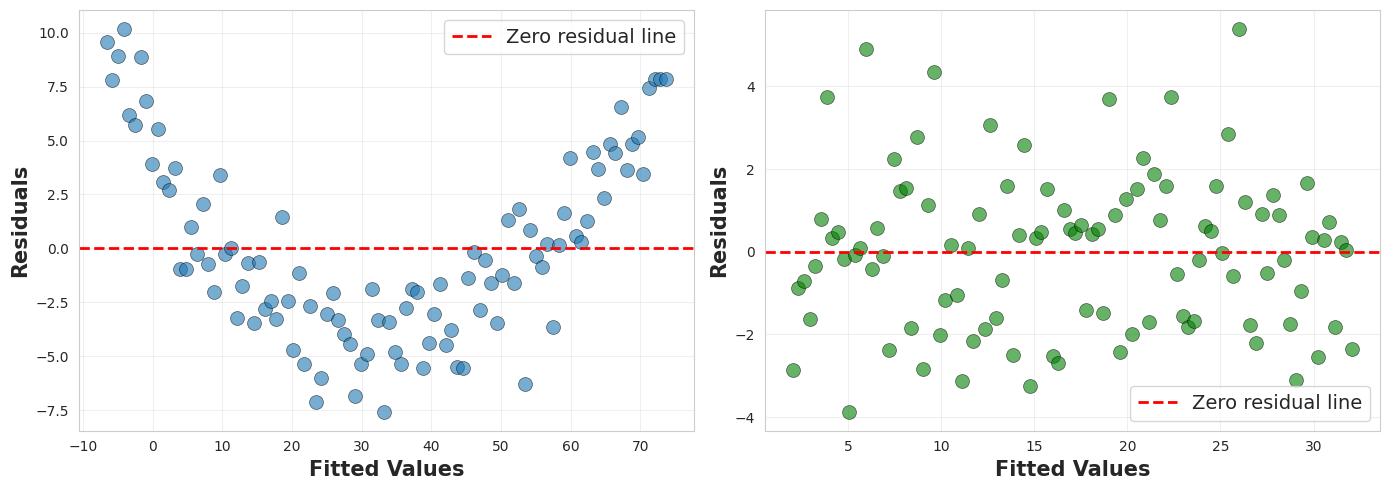


Plot characteristics:
Left plot: Shows systematic curved pattern - indicates non-linear relationship
Right plot: Shows random scatter around zero - indicates linear relationship is appropriate


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import os

# Create figures directory if it doesn't exist
os.makedirs('figures', exist_ok=True)

# Set random seed for reproducibility
np.random.seed(42)

# Generate data
n = 100
x = np.linspace(0, 10, n)

# Case 1: Non-linear relationship (violates linearity assumption)
# Using a quadratic relationship
y_nonlinear = 2 + 3*x + 0.5*x**2 + np.random.normal(0, 2, n)

# Case 2: Linear relationship (satisfies linearity assumption)
y_linear = 2 + 3*x + np.random.normal(0, 2, n)

# Fit linear models
model_nonlinear = LinearRegression()
model_linear = LinearRegression()

X = x.reshape(-1, 1)
model_nonlinear.fit(X, y_nonlinear)
model_linear.fit(X, y_linear)

# Calculate predictions and residuals
y_pred_nonlinear = model_nonlinear.predict(X)
y_pred_linear = model_linear.predict(X)

residuals_nonlinear = y_nonlinear - y_pred_nonlinear
residuals_linear = y_linear - y_pred_linear

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Deviation from linearity
axes[0].scatter(y_pred_nonlinear, residuals_nonlinear, alpha=0.6, s=100, edgecolors='k', linewidth=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero residual line')
axes[0].set_xlabel('Fitted Values', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Residuals', fontsize=15, fontweight='bold')
#axes[0].set_title('Residual Plot: Deviation from Linearity\n(Curved Pattern Indicates Non-linearity)', fontsize=13, fontweight='bold', pad=15)
axes[0].legend(fontsize=14)
axes[0].grid(True, alpha=0.3)

# Add a smooth curve to highlight the pattern
z = np.polyfit(y_pred_nonlinear, residuals_nonlinear, 2)
p = np.poly1d(z)
x_smooth = np.linspace(y_pred_nonlinear.min(), y_pred_nonlinear.max(), 100)
#axes[0].plot(x_smooth, p(x_smooth), 'b-', linewidth=2, alpha=0.7, label='Pattern trend')

# Plot 2: Perfect linearity assumption
axes[1].scatter(y_pred_linear, residuals_linear, alpha=0.6, s=100, edgecolors='k', linewidth=0.5, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero residual line')
axes[1].set_xlabel('Fitted Values', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Residuals', fontsize=15, fontweight='bold')
#axes[1].set_title('Residual Plot: Satisfies Linearity Assumption\n(Random Scatter Around Zero)', fontsize=13, fontweight='bold', pad=15)
axes[1].legend(fontsize=14)
axes[1].grid(True, alpha=0.3)

# Adjust layout and save
plt.tight_layout()
plt.savefig('figures/residual_plots_comparison.pdf', dpi=300, bbox_inches='tight')
print("Residual plots saved to: figures/residual_plots_comparison.pdf")
plt.show()
# Close the plot
plt.close()

print("\nPlot characteristics:")
print("Left plot: Shows systematic curved pattern - indicates non-linear relationship")
print("Right plot: Shows random scatter around zero - indicates linear relationship is appropriate")